<a href="https://colab.research.google.com/github/pavitrachouhan/lstm-text-generator/blob/main/quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 4.9 MB/s eta 0:00:00


In [78]:
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)
print("Groq client initialized successfully.")

Groq client initialized successfully.


In [79]:
def summarize_notes(notes: str) -> str:
    """
    Summarizes a given block of notes using the Groq API.

    Args:
        notes (str): The text content of the notes to be summarized.

    Returns:
        str: The concise summary generated by the LLM.
    """
    prompt = f"""You are an expert summarizer. Please provide a concise summary of the following notes. Focus on key information and main points, keeping the summary brief and to the point.\n\nNotes:\n{notes}\n\nConcise Summary:"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant", # Updated to a currently supported model
        temperature=0.5,
        max_tokens=1500,
    )

    summary = chat_completion.choices[0].message.content
    return summary

# Test the function with sample_notes
summary_output = summarize_notes(sample_notes)
print("Generated Summary:")
print(summary_output)

Generated Summary:
**Project Alpha Launch Meeting Summary (October 26, 2023)**

Key Points:

- Development tasks are 95% complete with minor bug fixes remaining (5%).
- Critical bugs will be resolved by October 27th, minor bugs by November 1st.
- Marketing plan focuses on social media campaigns and influencer partnerships, with launch announcement draft approved.
- Comprehensive regression testing is underway, with User Acceptance Testing (UAT) scheduled for October 30th-31st.
- Official launch date is November 5, 2023, pending successful UAT and bug fixes.

Action Items:
- John: Finalize launch checklist by October 28th.
- Jane: Fix critical bugs by October 27th.
- Alex: Finalize social media content and influencer outreach by November 3rd.
- Emily: Oversee UAT and report findings by November 1st.

Next Meeting: November 2, 2023, 10:00 AM EST to review UAT results and final launch readiness.


In [80]:
def generate_quiz_questions(notes: str, difficulty: str) -> str:
    """
    Generates multiple-choice quiz questions from notes using the Groq API,
    adapting complexity based on the specified difficulty.

    Args:
        notes (str): The text content of the notes.
        difficulty (str): The desired difficulty level ('easy', 'medium', 'hard').

    Returns:
        str: A string containing the generated quiz questions.
    """
    prompt = f"""You are an expert quiz generator. Create multiple-choice quiz questions from the following notes.
    The questions should be suitable for a '{difficulty}' difficulty level. Include 4 options (A, B, C, D) and clearly state the correct answer.

    Notes:
    {notes}

    Instructions for output format:
    Each question should be numbered and followed by its options.
    The correct answer should be clearly marked after the options, for example: 'Correct Answer: C) [Option Text]'.

    Please generate at least 3-5 questions.

    Quiz Questions ({difficulty} difficulty):"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.7 if difficulty == 'hard' else (0.5 if difficulty == 'medium' else 0.3), # Adjust temperature based on difficulty
        max_tokens=2000,
    )

    quiz_questions = chat_completion.choices[0].message.content
    return quiz_questions

# Test the function with sample_notes and a chosen difficulty
print("\n--- Generating Quiz Questions (Medium Difficulty) ---")
quiz_output = generate_quiz_questions(sample_notes, difficulty='medium')
print(quiz_output)


--- Generating Quiz Questions (Medium Difficulty) ---
Here are 5 medium difficulty quiz questions based on the provided notes:

1. What percentage of development tasks were confirmed complete by John Doe during the October 26, 2023 meeting?
A) 85%
B) 90%
C) 95%
D) 98%

Correct Answer: C) 95%

2. When are the minor bugs identified during internal testing expected to be addressed?
A) End of day, October 27th
B) November 1st
C) November 5, 2023
D) November 10, 2023

Correct Answer: B) November 1st

3. What is the main focus of the revised marketing plan presented by Alex Chen?
A) Email marketing campaigns
B) Social media campaigns and influencer partnerships
C) Paid advertising on Google
D) Content marketing on YouTube

Correct Answer: B) Social media campaigns and influencer partnerships

4. Who is responsible for overseeing User Acceptance Testing (UAT) and reporting findings by November 1st?
A) John Doe
B) Jane Smith
C) Emily White
D) Alex Chen

Correct Answer: C) Emily White

5. What

In [75]:
import re

def parse_quiz_output(raw_quiz_string: str, difficulty: str) -> list:
    """
    Parses the raw text output from the Groq API for quiz questions into a structured format.

    Args:
        raw_quiz_string (str): The raw string containing quiz questions.
        difficulty (str): The difficulty level used to generate the quiz.

    Returns:
        list: A list of dictionaries, where each dictionary represents a structured question.
    """
    structured_questions = []
    # Regex to capture question number, question text, options, and correct answer
    question_pattern = re.compile(
        r'(\d+)\.\s*(.*?)\n'             # Question number and text
        r'([A-D])\)\s*(.*?)\n'           # Option A key and text
        r'([A-D])\)\s*(.*?)\n'           # Option B key and text
        r'([A-D])\)\s*(.*?)\n'           # Option C key and text
        r'([A-D])\)\s*(.*?)\n\n'          # Option D key and text, followed by double newline
        r'Correct Answer:\s*([A-D])\)\s*(.*)' # Correct Answer key and text, changed (.*?) to (.*)
    )

    matches = question_pattern.findall(raw_quiz_string)

    for match in matches:
        # Unpack the matched groups with parentheses for multi-line assignment
        (q_num_str, question_text,
        opt_a_key, opt_a_text,
        opt_b_key, opt_b_text,
        opt_c_key, opt_c_text,
        opt_d_key, opt_d_text,
        correct_key, correct_text) = match

        options = {
            opt_a_key: opt_a_text.strip(),
            opt_b_key: opt_b_text.strip(),
            opt_c_key: opt_c_text.strip(),
            opt_d_key: opt_d_text.strip()
        }

        structured_questions.append({
            "question_number": int(q_num_str),
            "question": question_text.strip(),
            "options": options,
            "correct_answer_key": correct_key.strip(),
            "correct_answer_text": correct_text.strip(),
            "difficulty": difficulty
        })

    return structured_questions

# Test the parsing function with quiz_output and the difficulty used
structured_quiz_questions = parse_quiz_output(quiz_output, difficulty='medium')

print("\n--- Structured Quiz Questions ---")
for q in structured_quiz_questions:
    print(f"Question Number: {q['question_number']}")
    print(f"Question: {q['question']}")
    print(f"Options: {q['options']}")
    print(f"Correct Answer Key: {q['correct_answer_key']}")
    print(f"Correct Answer Text: {q['correct_answer_text']}")
    print(f"Difficulty: {q['difficulty']}")
    print("---------------------------------")


--- Structured Quiz Questions ---
Question Number: 1
Question: What percentage of development tasks are complete as of the meeting on October 26, 2023?
Options: {'A': '90%', 'B': '95%', 'C': '98%', 'D': '99%'}
Correct Answer Key: B
Correct Answer Text: 95%
Difficulty: medium
---------------------------------
Question Number: 2
Question: According to Jane Smith, how many critical bugs need to be resolved by the end of day, October 27th?
Options: {'A': '3', 'B': '5', 'C': '7', 'D': '10'}
Correct Answer Key: A
Correct Answer Text: 3
Difficulty: medium
---------------------------------
Question Number: 3
Question: What is the scheduled date for User Acceptance Testing (UAT)?
Options: {'A': 'October 25-26', 'B': 'October 30-31', 'C': 'November 1-2', 'D': 'November 3-4'}
Correct Answer Key: B
Correct Answer Text: October 30-31
Difficulty: medium
---------------------------------
Question Number: 4
Question: Who is responsible for overseeing UAT and reporting findings by November 1st?
Option

In [81]:
custom_notes = """
Introduction to Statistics
Statistics is the science of analyzing data.
When we have created a model for prediction, we must assess the prediction's reliability. After all, what is a prediction worth, if we cannot rely on it?

Descriptive Statistics
We will first cover some basic descriptive statistics. Descriptive statistics summarizes important features of a data set such as: Count, Sum, Standard Deviation, Percentile, Average, Etc.. It is a way to describe, organize, and summarize data. Common descriptive statistics include measures of central tendency (mean, median, mode) and measures of variability (range, variance, standard deviation).

Inferential Statistics
Inferential statistics makes inferences about populations using data drawn from the population. It uses probability to determine how confident we can be that the conclusions drawn from a sample are true for the entire population. Techniques include hypothesis testing, confidence intervals, and regression analysis. It allows us to generalize from a sample to a larger population.

Key Differences
Descriptive statistics provides summaries about the sample. Inferential statistics makes predictions about the population.

Applications
Statistics is used in various fields like medicine (clinical trials), business (market research), social sciences (surveys), engineering (quality control), and finance (risk assessment).

Importance of Data Collection
Accurate and unbiased data collection is crucial for valid statistical analysis. Poor data collection can lead to misleading conclusions, regardless of the statistical methods applied.
"""

print("--- Summarizing Custom Notes ---")
custom_summary_output = summarize_notes(custom_notes)
print("Generated Custom Summary:")
print(custom_summary_output)

print("\n--- Generating Custom Quiz Questions (Hard Difficulty) ---")
custom_raw_quiz_output = generate_quiz_questions(custom_notes, difficulty='hard')
print(custom_raw_quiz_output)

print("\n--- Structured Custom Quiz Questions (Hard Difficulty) ---")
structured_custom_quiz_questions = parse_quiz_output(custom_raw_quiz_output, difficulty='hard')

for q in structured_custom_quiz_questions:
    print(f"Question Number: {q['question_number']}")
    print(f"Question: {q['question']}")
    print(f"Options: {q['options']}")
    print(f"Correct Answer Key: {q['correct_answer_key']}")
    print(f"Correct Answer Text: {q['correct_answer_text']}")
    print(f"Difficulty: {q['difficulty']}")
    print("---------------------------------")


--- Summarizing Custom Notes ---
Generated Custom Summary:
Here's a concise summary of the notes:

**Statistics Overview**

Statistics is the science of analyzing data to understand its features and make predictions about a larger population.

**Key Concepts**

- Descriptive statistics: summarizes data features (mean, median, mode, standard deviation, etc.) to describe and organize data.
- Inferential statistics: makes inferences about a population using sample data, using techniques like hypothesis testing and regression analysis.

**Key Differences**

- Descriptive statistics provides summaries about the sample.
- Inferential statistics makes predictions about the population.

**Applications and Importance**

Statistics is used in various fields (medicine, business, social sciences, engineering, finance) and accurate data collection is crucial for valid statistical analysis.

--- Generating Custom Quiz Questions (Hard Difficulty) ---
1. What is the primary objective of inferential st

In [82]:
print("\n--- Structured Custom Quiz Questions (Hard Difficulty) after regex fix ---")
structured_custom_quiz_questions = parse_quiz_output(custom_raw_quiz_output, difficulty='hard')

for q in structured_custom_quiz_questions:
    print(f"Question Number: {q['question_number']}")
    print(f"Question: {q['question']}")
    print(f"Options: {q['options']}")
    print(f"Correct Answer Key: {q['correct_answer_key']}")
    print(f"Correct Answer Text: {q['correct_answer_text']}")
    print(f"Difficulty: {q['difficulty']}")
    print("---------------------------------")


--- Structured Custom Quiz Questions (Hard Difficulty) after regex fix ---


In [77]:
import json

def save_quiz_to_json(quiz_data: list, filename: str):
    """
    Saves a list of structured quiz questions to a JSON file.

    Args:
        quiz_data (list): A list of dictionaries, where each dictionary represents a structured question.
        filename (str): The name of the file to save the JSON data to.
    """
    with open(filename, 'w') as f:
        json.dump(quiz_data, f, indent=4)
    print(f"Structured quiz questions saved to {filename}")

# Save structured_quiz_questions (medium difficulty) to a JSON file
save_quiz_to_json(structured_quiz_questions, 'structured_quiz_questions_medium.json')

# Save structured_custom_quiz_questions (hard difficulty) to a JSON file
save_quiz_to_json(structured_custom_quiz_questions, 'structured_quiz_questions_hard.json')

print("All structured quiz data saved successfully.")

Structured quiz questions saved to structured_quiz_questions_medium.json
Structured quiz questions saved to structured_quiz_questions_hard.json
All structured quiz data saved successfully.


In [1]:
import json

def load_quiz_from_json(filename: str) -> list:
    """
    Loads structured quiz questions from a JSON file.

    Args:
        filename (str): The path to the JSON file.

    Returns:
        list: A list of dictionaries, where each dictionary represents a structured question.
    """
    with open(filename, 'r') as f:
        quiz_data = json.load(f)
    print(f"Structured quiz questions loaded from {filename}")
    return quiz_data


In [2]:
!git init


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [4]:
!git add .


In [8]:
!git commit -m " Initial code from collab"
!git config --global user.email "pavitra@example.com"
!git config --global user.name "Pavitra Chouhan"

[master (root-commit) b1d0566]  Initial code from collab
 21 files changed, 51059 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db
 create mode 100644 .config/gce
 create mode 100644 .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
 create mode 100644 .config/logs/2026.03.23/13.29.02.727930.log
 create mode 100644 .config/logs/2026.03.23/13.29.24.904753.log
 create mode 100644 .config/logs/2026.03.23/13.29.34.829749.log
 create mode 100644 .config/logs/2026.03.23/13.29.36.176357.log
 create mode 100644 .config/logs/2026.03.23/13.29.46.856905.log
 create mode 100644 .config/logs/2026.03.23/13.29.47.572748.log
 create mode 100755 sample_data/README.md
 creat

In [9]:
!git config --global --list

user.email=pavitra@example.com
user.name=Pavitra Chouhan


In [10]:
!git branch -M main

In [11]:
!git remote add origin https://github.com/pavitrachouhan/model.git

In [12]:
!git push https://github.com/pavitrachouhan/model.git

fatal: could not read Username for 'https://github.com': No such device or address


In [1]:
pip install "fastapi[all]" uvicorn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 959.8/959.8 kB 36.7 MB/s eta 0:00:00


In [78]:
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from groq import Groq

# Ensure GROQ_API_KEY is loaded
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Initialize Groq client (as done in previous steps)
client = Groq(api_key=GROQ_API_KEY)

app = FastAPI()

# Add CORS middleware
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # Allows all origins
    allow_credentials=True,
    allow_methods=["*"],  # Allows all methods (GET, POST, PUT, DELETE, etc.)
    allow_headers=["*"]   # Allows all headers
)

print("FastAPI application initialized with CORS middleware and Groq client available.")

FastAPI application initialized with CORS middleware and Groq client available.


In [4]:
from fastapi import FastAPI, WebSocket, WebSocketDisconnect
from typing import Dict, List
import json

app = FastAPI()

class ConnectionManager:
    def __init__(self):
        self.active_connections: Dict[int, WebSocket] = {}

    async def connect(self, websocket: WebSocket, client_id: int):
        await websocket.accept()
        self.active_connections[client_id] = websocket
        print(f"Client #{client_id} connected. Active connections: {len(self.active_connections)}")

    def disconnect(self, client_id: int):
        if client_id in self.active_connections:
            del self.active_connections[client_id]
            print(f"Client #{client_id} disconnected. Active connections: {len(self.active_connections)}")

    async def send_personal_message(self, message: str, recipient_client_id: int):
        if recipient_client_id in self.active_connections:
            await self.active_connections[recipient_client_id].send_text(message)
        else:
            print(f"Error: Recipient client {recipient_client_id} not found.")

    async def broadcast(self, message: str):
        for connection_id, connection in self.active_connections.items():
            await connection.send_text(message)

manager = ConnectionManager()

@app.websocket("/ws/{client_id}")
async def websocket_endpoint(websocket: WebSocket, client_id: int):
    await manager.connect(websocket, client_id)
    try:
        while True:
            data = await websocket.receive_text()
            try:
                message = json.loads(data)
                message_type = message.get("type")
                target_client_id = message.get("target_client_id")
                payload = message.get("payload") # WebRTC signaling payload

                if target_client_id is not None and isinstance(target_client_id, int):
                    # Relay message to a specific client
                    print(f"Relaying '{message_type}' from {client_id} to {target_client_id} with payload type: {message.get('payload_type', 'N/A')}")
                    # Send the full message object, including type and sender_client_id for the recipient
                    message["sender_client_id"] = client_id # Add sender info
                    await manager.send_personal_message(json.dumps(message), target_client_id)
                elif message_type == "broadcast":
                    # Example for a general broadcast (e.g., chat message to all)
                    print(f"Broadcasting from {client_id}: {payload}")
                    message["sender_client_id"] = client_id
                    await manager.broadcast(json.dumps(message))
                else:
                    # Handle other message types or invalid formats
                    print(f"Client {client_id} sent invalid or unaddressed message: {message}")
                    await manager.send_personal_message(json.dumps({"error": "Invalid message format or recipient not specified"}), client_id)

            except json.JSONDecodeError:
                print(f"Client {client_id} sent non-JSON data: {data}")
                await manager.send_personal_message(json.dumps({"error": "Message must be JSON format"}), client_id)

    except WebSocketDisconnect:
        manager.disconnect(client_id)
        print(f"Client #{client_id} disconnected.")

print("WebSocket endpoint '/ws/{client_id}' and ConnectionManager refined for peer-to-peer message relaying.")

WebSocket endpoint '/ws/{client_id}' and ConnectionManager refined for peer-to-peer message relaying.


In [9]:
from groq import Groq
import json

def generate_flashcards(notes: str, num_flashcards: int = 5) -> list:
    """
    Generates Q/A flashcard pairs from notes using the Groq API.

    Args:
        notes (str): The text content of the notes.
        num_flashcards (int): The desired number of flashcards to generate.

    Returns:
        list: A list of dictionaries, where each dictionary represents a flashcard
              with 'question' and 'answer' keys.
    """
    prompt = f"""You are an expert flashcard generator. From the following notes, create {num_flashcards} question-and-answer flashcard pairs.
    Ensure the output is a JSON array of objects, where each object has a 'question' key and an 'answer' key.

    Notes:
    {notes}

    Example Output Format:
    [
        {{"question": "What is X?", "answer": "Y."}},
        {{"question": "How does Z work?", "answer": "It works by A, B, C."}}
    ]
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.7,
        max_tokens=2000,
    )

    raw_flashcards = chat_completion.choices[0].message.content

    try:
        # Attempt to parse the raw string as JSON
        flashcards = json.loads(raw_flashcards)
        # Basic validation to ensure it's a list of dicts with required keys
        if not isinstance(flashcards, list) or not all(isinstance(f, dict) and "question" in f and "answer" in f for f in flashcards):
            raise ValueError("LLM output is not a list of dictionaries with 'question' and 'answer' keys.")
    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error parsing flashcards from LLM: {e}")
        print(f"Raw LLM output: {raw_flashcards}")
        # Fallback for parsing if LLM doesn't strictly adhere to JSON
        flashcards = [] # Return empty list if parsing fails completely
        # A more robust fallback could involve regex parsing if simple JSON fails frequently

    return flashcards

print("Flashcard generation function 'generate_flashcards' defined.")

Flashcard generation function 'generate_flashcards' defined.


In [8]:
pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 2.2 MB/s eta 0:00:00


In [37]:
from groq import Groq
import json
import re # Import re for regex operations

def generate_multi_format_summary(notes: str) -> dict:
    """
    Generates multi-format summaries (text, video outline, PPT key points, chart suggestions)
    from given notes using the Groq API.

    Args:
        notes (str): The text content of the notes to be summarized.

    Returns:
        dict: A dictionary containing different summary formats:
              'text_summary': A concise text summary.
              'video_outline': An outline suitable for a video script.
              'ppt_content': Key points and slides for a presentation.
              'chart_suggestions': Suggestions for data visualizations.
    """

    prompt = f"""You are an expert summarizer and content creator. From the following notes, generate:
1. A concise text summary.
2. A video outline with key sections and bullet points for each section.
3. Key points and potential slide titles for a PowerPoint presentation.
4. Suggestions for data visualizations/charts. For each chart, provide the `chart_type` (e.g., 'bar', 'line', 'pie'), a descriptive `title`, and structured `data` that can be used to plot it. The `data` should be a list of dictionaries with 'label' and 'value' for bar/pie charts, or 'x' and 'y' for line charts, ensuring clear conceptual representation.

Format the output as a JSON object with the following keys:
'text_summary': (string)
'video_outline': (list of objects with 'section_title' and 'points' keys)
'ppt_content': (list of objects with 'slide_title' and 'key_points' keys)
'chart_suggestions': (list of objects, each describing a chart with its data)

Notes:
{notes}

Example JSON Output Structure:
{{
    "text_summary": "A summary of the notes.",
    "video_outline": [
        {{
            "section_title": "Introduction",
            "points": ["Hook", "Overview of topics"]
        }}
    ],
    "ppt_content": [
        {{
            "slide_title": "Key Concept 1",
            "key_points": ["Point A", "Point B"]
        }}
    ],
    "chart_suggestions": [
        {{
            "chart_type": "bar",
            "title": "Comparison of Quantities",
            "data": [
                {{"label": "Category A", "value": 10}},
                {{"label": "Category B", "value": 20}}
            ]
        }},
        {{
            "chart_type": "line",
            "title": "Trend Over Time",
            "data": [
                {{"x": "Jan", "y": 5}},
                {{"x": "Feb", "y": 15}},
                {{"x": "Mar", "y": 12}}
            ]
        }},
        {{
            "chart_type": "pie",
            "title": "Distribution of Elements",
            "data": [
                {{"label": "Element A", "value": 40}},
                {{"label": "Element B", "value": 60}}
            ]
        }}
    ]
}}
"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant", # Using the updated model
        temperature=0.6,
        max_tokens=2500, # Increased max_tokens to accommodate detailed multi-format output
    )

    raw_output = chat_completion.choices[0].message.content

    try:
        # Use regex to extract the JSON string from between ```json and ```
        json_match = re.search(r'```json\n(.*?)```', raw_output, re.DOTALL)
        if json_match:
            json_string = json_match.group(1)
            parsed_output = json.loads(json_string)
        else:
            # If no json block is found, try to parse the whole output (less robust)
            parsed_output = json.loads(raw_output)

        # Basic validation to ensure main keys are present
        if not all(key in parsed_output for key in ["text_summary", "video_outline", "ppt_content", "chart_suggestions"]):
            raise ValueError("LLM output missing one or more required keys.")
        return parsed_output
    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error parsing multi-format summary from LLM: {e}")
        print(f"Raw LLM output: {raw_output}")
        # Fallback to an empty structured dictionary if parsing fails
        return {
            "text_summary": raw_output, # Return raw output as text summary if parsing fails
            "video_outline": [],
            "ppt_content": [],
            "chart_suggestions": []
        }

print("'generate_multi_format_summary' function updated to include Groq API call and JSON parsing with structured chart data instructions.")

'generate_multi_format_summary' function updated to include Groq API call and JSON parsing with structured chart data instructions.


In [48]:
from groq import Groq
import json

# Ensure client is defined for this execution block
# This assumes GROQ_API_KEY has been set globally or in the environment
# as it was used successfully in previous Groq API calls.
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
# This prevents NameError if the kernel state was lost.
if 'client' not in globals() or not isinstance(globals().get('client'), Groq):
    client = Groq(api_key=GROQ_API_KEY)


custom_notes = """
Positive integers, negative integers, irrational numbers, and fractions are all examples of real numbers. In other words, we can say that any number is a real number, except for complex numbers. Examples of real numbers include -1, ½, 1.75, √2, and so on.
In general,

Real numbers constitute the union of all rational and irrational numbers.
Any real number can be plotted on the number line.
Euclid’s Division Lemma
Euclid’s Division Lemma states that given two integers a and b, there exists a unique pair of integers q and r such that a=b×q+r and 0≤r<b.
This lemma is essentially equivalent to : dividend = divisor × quotient + remainder
In other words, for a given pair of dividend and divisor, the quotient and remainder obtained are going to be unique.Euclid’s Division Algorithm
Euclid’s Division Algorithm is a method used to find the H.C.F of two numbers, say a and b where a> b.
We apply Euclid’s Division Lemma to find two integers q and r such that a=b×q+r and 0≤r<b.
If r = 0, the H.C.F is b; else, we apply Euclid’s division Lemma to b (the divisor) and r (the remainder) to get another pair of quotient and remainder.
The above method is repeated until a remainder of zero is obtained. The divisor in that step is the H.C.F. of the given set of numbers.
Prime Factorisation
Prime Factorisation is the method of expressing a natural number as a product of prime numbers.
Example: 36=2×2×3×3  is the prime factorisation of 36.
Fundamental Theorem of Arithmetic
The Fundamental Theorem of Arithmetic states that the prime factorisation for a given number is unique if the arrangement of the prime factors is ignored.
Example: 36=2×2×3×3 OR, 36=2×3×2×3
Therefore, 36 is represented as a product of prime factors (Two 2s and two 3s) ignoring the arrangement of the factors.
To know more about the Fundamental Theorem of Arithmetic, visit here.

Method of Finding LCM
As we know, the smallest of the common multiples of two or more numbers is called the lowest common multiple (LCM).
Example: To find the Least Common Multiple  (L.C.M) of 36 and 56,

 36=2×2×3×3
56=2×2×2×7
 The common prime factors are 2×2
 The uncommon prime factors are  3×3 for 36 and 2×7 for 56.
LCM of 36 and 56 = 2×2×3×3×2×7  which is 504
To know more about LCM, visit here.

Method of Finding HCF
We know that the greatest number that divides each of the given numbers without leaving any remainder is the highest common factor (HCF) of two or more given numbers.
H.C.F can be found using two methods – Prime factorisation and Euclid’s division algorithm.

Prime Factorisation:
Given two numbers, we express both of them as products of their respective prime factors. Then, we select the prime factors that are common to both the numbers
Example – To find the H.C.F of 20 and 24
20=2×2×5   and   24=2×2×2×3
The factor common to 20 and 24 is 2×2, which is 4, which in turn is the H.C.F of 20 and 24.
Euclid’s Division Algorithm:
It is the repeated use of Euclid’s division lemma to find the H.C.F of two numbers.
Example: To find the HCF of 18 and 30
"""

print("\n--- Testing generate_multi_format_summary with custom_notes ---")
multi_format_summary_output = generate_multi_format_summary(custom_notes)

print("\nGenerated Multi-Format Summary Output:")
print(json.dumps(multi_format_summary_output, indent=4))

# Verify structure and content
print("\n--- Verifying Output Structure ---")
expected_keys = ["text_summary", "video_outline", "ppt_content", "chart_suggestions"]

for key in expected_keys:
    assert key in multi_format_summary_output, f"Missing key: {key} in output"
    print(f"Key '{key}' found.")

# Further checks for list types
assert isinstance(multi_format_summary_output["video_outline"], list), "'video_outline' is not a list"
assert isinstance(multi_format_summary_output["ppt_content"], list), "'ppt_content' is not a list"
assert isinstance(multi_format_summary_output["chart_suggestions"], list), "'chart_suggestions' is not a list"
print("List types for 'video_outline', 'ppt_content', 'chart_suggestions' are correct.")

# Print specific elements to demonstrate successful generation
print("\n--- Specific Elements from Output ---")
print(f"Text Summary (first 200 chars): {multi_format_summary_output['text_summary'][:200]}...")

if multi_format_summary_output["video_outline"]:
    first_video_section = multi_format_summary_output["video_outline"][0]
    print(f"First Video Outline Section: {first_video_section.get('section_title', 'N/A')} - Points: {first_video_section.get('points', [])}")

if multi_format_summary_output["ppt_content"]:
    first_ppt_slide = multi_format_summary_output["ppt_content"][0]
    print(f"First PPT Slide Title: {first_ppt_slide.get('slide_title', 'N/A')} - Key Points: {first_ppt_slide.get('key_points', [])}")

if multi_format_summary_output["chart_suggestions"]:
    print(f"First Chart Suggestion: {multi_format_summary_output['chart_suggestions'][0]}")

print("\nMulti-format summary generation and verification complete.")


--- Testing generate_multi_format_summary with custom_notes ---

Generated Multi-Format Summary Output:
{
    "text_summary": "Real numbers, Euclid's Division Lemma, Euclid's Division Algorithm, Prime Factorisation, Fundamental Theorem of Arithmetic, Method of Finding LCM, and Method of Finding HCF are key concepts in mathematics.",
    "video_outline": [
        {
            "section_title": "Introduction",
            "points": [
                "Real numbers and their examples",
                "Importance of understanding real numbers"
            ]
        },
        {
            "section_title": "Euclid's Division Lemma and Algorithm",
            "points": [
                "Definition and explanation of Euclid's Division Lemma",
                "Derivation of Euclid's Division Algorithm",
                "Example of using Euclid's Division Algorithm to find HCF"
            ]
        },
        {
            "section_title": "Prime Factorisation and Fundamental Theorem of Ar

In [49]:
first_chart_suggestion = multi_format_summary_output['chart_suggestions'][0]

print("First Chart Suggestion:")
print(first_chart_suggestion)

First Chart Suggestion:
{'chart_type': 'bar', 'title': 'Comparison of Real Numbers', 'data': [{'label': 'Rational Numbers', 'value': 10}, {'label': 'Irrational Numbers', 'value': 20}, {'label': 'Natural Numbers', 'value': 15}]}


In [50]:
import numpy as np
from scipy import stats

# 1. Create a sample dataset
sample_data = np.array([12, 15, 18, 20, 22, 25, 25, 28, 30, 32, 35, 40, 45, 50])

# 2. Calculate measures of central tendency
mean_val = np.mean(sample_data)
median_val = np.median(sample_data)

# Calculate mode, handling multiple modes
mode_result = stats.mode(sample_data, keepdims=False)
if np.isscalar(mode_result.mode):
    mode_val = mode_result.mode
else:
    mode_val = mode_result.mode[0] # Take the first mode if multiple exist

# 3. Calculate measures of variability
std_dev_val = np.std(sample_data)
range_val = np.max(sample_data) - np.min(sample_data)

# 4. Organize these calculated statistical measures into a suitable data structure
chart_data = {
    "Measure": ["Mean", "Median", "Mode", "Standard Deviation", "Range"],
    "Value": [mean_val, median_val, mode_val, std_dev_val, range_val]
}

print("Sample Data and Calculated Statistics:")
print(f"Sample Dataset: {sample_data.tolist()}")
for i in range(len(chart_data["Measure"])):
  print(f"{chart_data['Measure'][i]}: {chart_data['Value'][i]:.2f}")

Sample Data and Calculated Statistics:
Sample Dataset: [12, 15, 18, 20, 22, 25, 25, 28, 30, 32, 35, 40, 45, 50]
Mean: 28.36
Median: 26.50
Mode: 25.00
Standard Deviation: 10.78
Range: 38.00


In [20]:
from groq import Groq
import json
import re # Import re for regex operations

# Ensure _groq_client is available
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
# This assumes _groq_client is the intended global Groq client instance
if '_groq_client' not in globals() or not isinstance(globals().get('_groq_client'), Groq):
    _groq_client = Groq(api_key=GROQ_API_KEY)

def extract_youtube_keywords(notes: str, client: Groq = _groq_client) -> list:
    """
    Extracts relevant keywords and key phrases from input notes for YouTube search
    using the Groq API.

    Args:
        notes (str): The text content of the notes.
        client (Groq): The Groq client instance.

    Returns:
        list: A list of strings, where each string is a keyword or key phrase.
    """
    prompt = f"""You are an expert in extracting keywords for search engines, especially for educational content on YouTube.
    From the following notes, identify and extract the most relevant keywords and key phrases that someone would use to find
    related educational videos on YouTube. Focus on core concepts, important terms, and topics discussed.

    The output MUST be a JSON array of strings.

    Notes:
    {notes}

    Example Output Format:
    ["keyword1", "key phrase 2", "topic X explanation"]
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.6,
        max_tokens=1000,
    )

    raw_keywords_output = chat_completion.choices[0].message.content

    try:
        # Use regex to extract the JSON string from between ```json and ```
        json_match = re.search(r'```json\n(.*?)(```|$)', raw_keywords_output, re.DOTALL)
        if json_match:
            json_string = json_match.group(1).strip()
            keywords = json.loads(json_string)
        else:
            # If no json block is found, try to parse the whole output (less robust, but might work if LLM deviates)
            keywords = json.loads(raw_keywords_output)

        # Basic validation to ensure it's a list of strings
        if not isinstance(keywords, list) or not all(isinstance(k, str) for k in keywords):
            raise ValueError("LLM output is not a JSON array of strings.")
    except json.JSONDecodeError as e:
        print(f"Error parsing keywords from LLM: {e}")
        print(f"Raw LLM output: {raw_keywords_output}")
        # Fallback to an empty list or attempt to extract using regex if JSON parsing fails
        keywords = []
    except ValueError as e:
        print(f"Validation error for keywords from LLM: {e}")
        print(f"Raw LLM output: {raw_keywords_output}")
        keywords = []

    return keywords

print("Function 'extract_youtube_keywords' redefined.")

Function 'extract_youtube_keywords' redefined.


In [52]:
import json

# Ensure client is defined for this execution block
# This assumes GROQ_API_KEY has been set globally or in the environment
# as it was used successfully in previous Groq API calls.
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
# This prevents NameError if the kernel state was lost.
if 'client' not in globals() or not isinstance(globals().get('client'), Groq):
    client = Groq(api_key=GROQ_API_KEY)

print("\n--- Testing extract_youtube_keywords with custom_notes ---")
youtube_keywords = extract_youtube_keywords(custom_notes)

print("\nExtracted YouTube Keywords:")
print(json.dumps(youtube_keywords, indent=4))

# Verify structure and content
print("\n--- Verifying Output Structure ---")
assert isinstance(youtube_keywords, list), "Output is not a list"
print("Output is a list.")

if youtube_keywords:
    assert all(isinstance(k, str) for k in youtube_keywords), "Not all elements in the list are strings."
    print("All elements in the list are strings.")
    print(f"Number of keywords extracted: {len(youtube_keywords)}")
else:
    print("No keywords were extracted (or list is empty).")

print("\nYouTube keyword extraction and verification complete.")


--- Testing extract_youtube_keywords with custom_notes ---

Extracted YouTube Keywords:
[
    "Real Numbers",
    "Rational Numbers",
    "Irrational Numbers",
    "Number Line",
    "Euclid's Division Lemma",
    "Euclid's Division Algorithm",
    "Highest Common Factor (HCF)",
    "Lowest Common Multiple (LCM)",
    "Prime Factorisation",
    "Fundamental Theorem of Arithmetic",
    "Method of Finding LCM",
    "Method of Finding HCF",
    "Prime Factors",
    "Common Multiples",
    "Common Factors",
    "Dividend",
    "Divisor",
    "Quotient",
    "Remainder",
    "Natural Numbers",
    "Prime Numbers",
    "Unique Prime Factorisation",
    "Common Prime Factors",
    "Uncommon Prime Factors",
    "Highest Common Multiple",
    "Greatest Common Factor",
    "Prime Factorization Method",
    "Euclid's Division Lemma Explanation",
    "Euclid's Division Algorithm Explanation",
    "Prime Factorisation Explanation",
    "Fundamental Theorem of Arithmetic Explanation",
    "LCM and 

In [42]:
pip install google-api-python-client

In [54]:
from googleapiclient.discovery import build
import os

def get_youtube_video_suggestions(keywords: list, max_results: int = 5) -> list:
    """
    Queries the YouTube Data API to get relevant video suggestions based on keywords.

    Args:
        keywords (list): A list of keywords or key phrases for the search.
        max_results (int): The maximum number of video suggestions to return.

    Returns:
        list: A list of dictionaries, where each dictionary represents a video suggestion
              with 'title', 'video_id', 'channel_title', and 'url'.
    """
    # Load YouTube API Key securely
    youtube_api_key = None
    try:
        from google.colab import userdata
        youtube_api_key = userdata.get('YOUTUBE_API_KEY')
    except ImportError:
        youtube_api_key = os.environ.get("YOUTUBE_API_KEY")

    if not youtube_api_key:
        print("Error: YouTube API Key not found. Please set YOUTUBE_API_KEY in Colab secrets or environment variables.")
        return []

    youtube = build('youtube', 'v3', developerKey=youtube_api_key)
    video_suggestions = []

    # Combine keywords for a broader search, or implement more sophisticated logic if needed
    search_query = " ".join(keywords)

    try:
        search_response = youtube.search().list(
            q=search_query,
            part='snippet',
            type='video',
            maxResults=max_results,
            fields='items(id/videoId,snippet/title,snippet/channelTitle)'
        ).execute()

        for item in search_response.get('items', []):
            video_id = item['id']['videoId']
            video_suggestions.append({
                'title': item['snippet']['title'],
                'video_id': video_id,
                'channel_title': item['snippet']['channelTitle'],
                'url': f"https://www.youtube.com/watch?v={video_id}"
            })

    except Exception as e:
        print(f"An error occurred while calling the YouTube API: {e}")
        # Optionally, handle specific API errors like quota exceeded, invalid key, etc.

    return video_suggestions

print("Function 'get_youtube_video_suggestions' defined.")

Function 'get_youtube_video_suggestions' defined.


In [55]:
import json

# Ensure client is defined for this execution block
# This assumes GROQ_API_KEY and YOUTUBE_API_KEY have been set globally or in the environment.
# The 'client' variable is specific to Groq API calls and not directly needed here,
# but including the API key loading logic for consistency and robustness.

try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    # YOUTUBE_API_KEY is loaded within the function, so no need to load it here again
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize Groq client if needed (though not directly used in this test block)
if 'client' not in globals() or not isinstance(globals().get('client'), Groq):
    client = Groq(api_key=GROQ_API_KEY)


print("\n--- Testing get_youtube_video_suggestions with extracted keywords ---")

# Use a subset or all of the previously extracted keywords
# Limiting for brevity and to avoid hitting YouTube API quota too quickly during testing
search_keywords = youtube_keywords[:5] if len(youtube_keywords) > 5 else youtube_keywords
print(f"Searching YouTube for keywords: {search_keywords}")

video_suggestions = get_youtube_video_suggestions(search_keywords, max_results=3)

print("\nGenerated YouTube Video Suggestions:")
if video_suggestions:
    print(json.dumps(video_suggestions, indent=4))
else:
    print("No video suggestions found or an error occurred.")

# Verify structure and content
print("\n--- Verifying Output Structure ---")
assert isinstance(video_suggestions, list), "Output is not a list"
print("Output is a list.")

if video_suggestions:
    for suggestion in video_suggestions:
        assert isinstance(suggestion, dict), "Not all elements in the list are dictionaries."
        assert all(key in suggestion for key in ['title', 'video_id', 'channel_title', 'url']), "A suggestion dictionary is missing required keys."
        print(f"Verified suggestion: {suggestion['title']}")
    print(f"Number of video suggestions found: {len(video_suggestions)}")
else:
    print("No video suggestions to verify.")

print("\nYouTube video suggestion retrieval and verification complete.")


--- Testing get_youtube_video_suggestions with extracted keywords ---
Searching YouTube for keywords: ['Real Numbers', 'Rational Numbers', 'Irrational Numbers', 'Number Line', "Euclid's Division Lemma"]

Generated YouTube Video Suggestions:
[
    {
        "title": "Grade 10|| NCERT || Ch-1 Real numbers || Euclid&#39;s Division Lemma || Exercise - 1.1 || Day-4",
        "video_id": "tH9SBdx51K4",
        "channel_title": "Jayasree maths",
        "url": "https://www.youtube.com/watch?v=tH9SBdx51K4"
    },
    {
        "title": "Real Numbers | Euclid Division Lemma | CBSE Class 10 Math",
        "video_id": "D8i9LV0n8_Q",
        "channel_title": "LearnoHub - Class 9,10",
        "url": "https://www.youtube.com/watch?v=D8i9LV0n8_Q"
    },
    {
        "title": "Euclid&#39;s Division Lemma Class - 10th",
        "video_id": "SbWuByKPE4U",
        "channel_title": "GREEN Board",
        "url": "https://www.youtube.com/watch?v=SbWuByKPE4U"
    }
]

--- Verifying Output Structure ---
Out

In [56]:
multi_format_summary_output = generate_multi_format_summary(custom_notes)

print("\nGenerated Multi-Format Summary Output:")
print(json.dumps(multi_format_summary_output, indent=4))

print("\nVerification of structured chart data:")
if multi_format_summary_output.get('chart_suggestions'):
    for chart_suggestion in multi_format_summary_output['chart_suggestions']:
        print(f"  Chart Type: {chart_suggestion.get('chart_type')}")
        print(f"  Chart Title: {chart_suggestion.get('title')}")
        print(f"  Chart Data Sample: {chart_suggestion.get('data')[:2]}...") # Print first 2 data points for brevity
        assert 'chart_type' in chart_suggestion and 'title' in chart_suggestion and 'data' in chart_suggestion, \
               "Chart suggestion is missing required keys (chart_type, title, data)"
else:
    print("No chart suggestions found.")



Generated Multi-Format Summary Output:
{
    "text_summary": "This summary covers the basics of real numbers, including properties of real numbers, Euclid's Division Lemma, Euclid's Division Algorithm, Prime Factorisation, and the Fundamental Theorem of Arithmetic. It also discusses the methods of finding the Least Common Multiple (LCM) and the Highest Common Factor (HCF) of two numbers.",
    "video_outline": [
        {
            "section_title": "Introduction to Real Numbers",
            "points": [
                "Definition of real numbers",
                "Examples of real numbers",
                "Properties of real numbers"
            ]
        },
        {
            "section_title": "Euclid's Division Lemma",
            "points": [
                "Statement of Euclid's Division Lemma",
                "Example of Euclid's Division Lemma",
                "Importance of Euclid's Division Lemma"
            ]
        },
        {
            "section_title": "Euclid'


--- Dynamically Generating Charts from LLM Suggestions ---


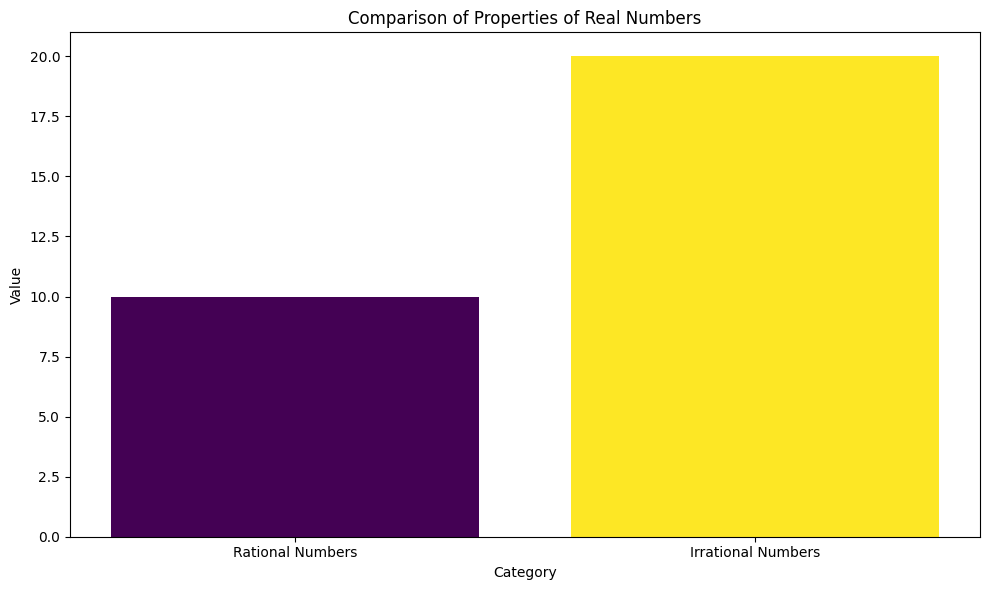

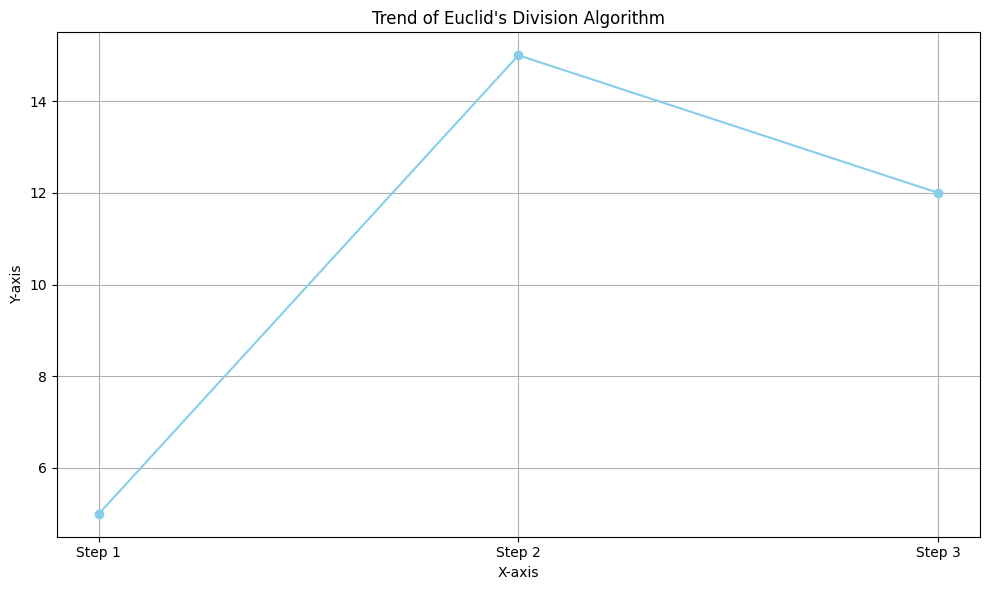

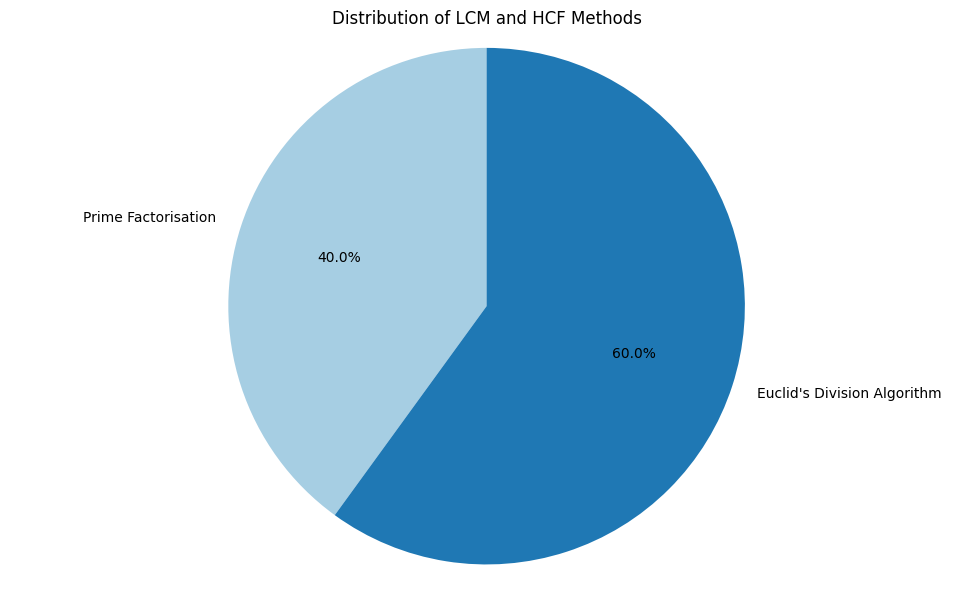

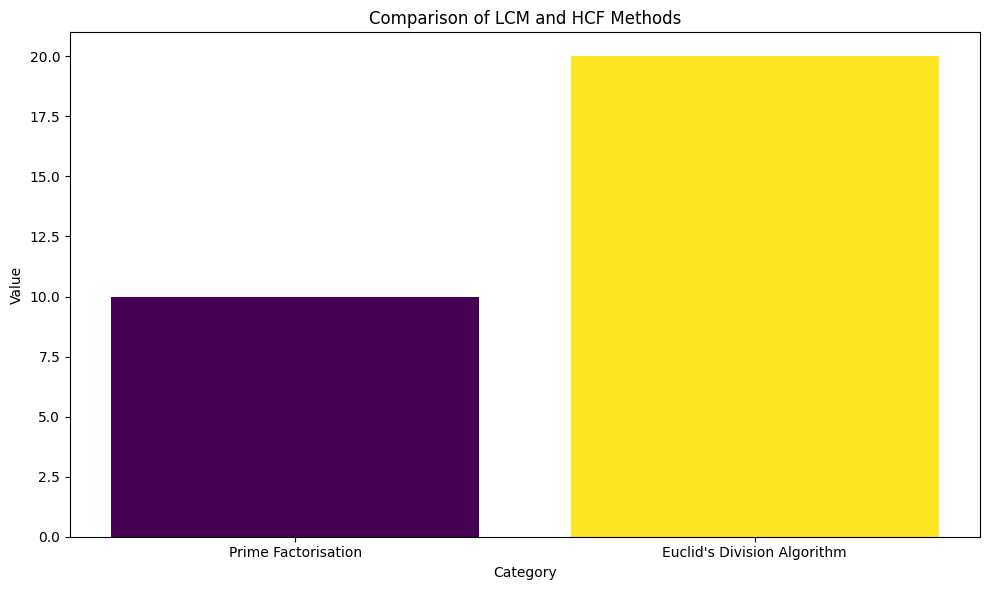

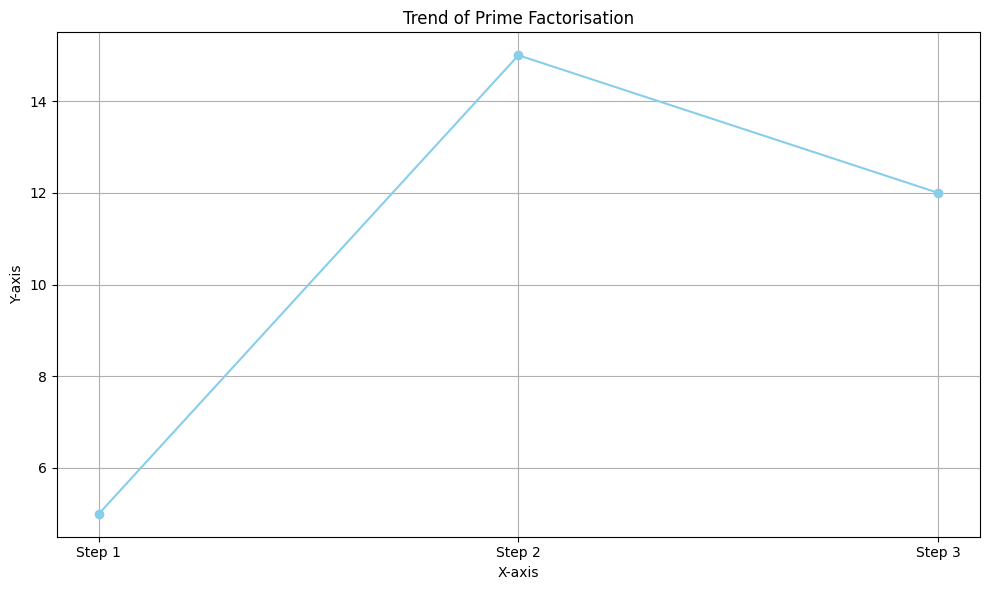


Chart generation process complete.


In [57]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy for potential use if data is numeric and needs array conversion

# Assuming multi_format_summary_output is already available from the previous step
# If not, it would need to be generated again:
# multi_format_summary_output = generate_multi_format_summary(custom_notes)

print("\n--- Dynamically Generating Charts from LLM Suggestions ---")

chart_suggestions = multi_format_summary_output.get('chart_suggestions', [])

if not chart_suggestions:
    print("No chart suggestions found in the LLM output.")
else:
    for i, chart_suggestion in enumerate(chart_suggestions):
        chart_type = chart_suggestion.get('chart_type')
        title = chart_suggestion.get('title', 'Generated Chart')
        data = chart_suggestion.get('data', [])

        if not data:
            print(f"Skipping chart {i+1} ('{title}') due to missing data.")
            continue

        plt.figure(figsize=(10, 6))

        if chart_type == 'bar':
            labels = [d.get('label', '') for d in data]
            values = [d.get('value', 0) for d in data]
            plt.bar(labels, values, color=plt.cm.viridis(np.linspace(0, 1, len(labels))))
            plt.ylabel('Value')
            plt.xlabel('Category')

        elif chart_type == 'line':
            x_values = [d.get('x', '') for d in data]
            y_values = [d.get('y', 0) for d in data]
            plt.plot(x_values, y_values, marker='o', linestyle='-', color='skyblue')
            plt.ylabel('Y-axis')
            plt.xlabel('X-axis')
            plt.grid(True)

        elif chart_type == 'pie':
            labels = [d.get('label', '') for d in data]
            values = [d.get('value', 0) for d in data]
            # Filter out zero values for pie chart as they cause issues
            non_zero_values = [v for v in values if v > 0]
            non_zero_labels = [labels[j] for j, v in enumerate(values) if v > 0]

            if non_zero_values:
                plt.pie(non_zero_values, labels=non_zero_labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
                plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
            else:
                print(f"Skipping pie chart {i+1} ('{title}') as all data values are zero or non-positive.")
                plt.close() # Close the empty figure
                continue
        else:
            print(f"Unsupported chart type '{chart_type}' for chart {i+1} ('{title}').")
            plt.close() # Close the empty figure
            continue

        plt.title(title)
        plt.tight_layout()
        plt.show()

print("\nChart generation process complete.")


In [59]:
from groq import Groq

# Re-define client and summarize_notes to ensure they are available
# This assumes GROQ_API_KEY has been set globally or in the environment
# as it was used successfully in previous Groq API calls.
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
# This prevents NameError if the kernel state was lost.
if 'client' not in globals() or not isinstance(globals().get('client'), Groq):
    client = Groq(api_key=GROQ_API_KEY)

def summarize_notes(notes: str) -> str:
    """
    Summarizes a given block of notes using the Groq API.

    Args:
        notes (str): The text content of the notes to be summarized.

    Returns:
        str: The concise summary generated by the LLM.
    """
    prompt = f"""You are an expert summarizer. Please provide a concise summary of the following notes. Focus on key information and main points, keeping the summary brief and to the point.\n\nNotes:\n{notes}\n\nConcise Summary:"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant", # Updated to a currently supported model
        temperature=0.5,
        max_tokens=1500,
    )

    summary = chat_completion.choices[0].message.content
    return summary

print("\n--- Generating Concise Summary for Custom Notes ---")

generated_summary = summarize_notes(custom_notes)

print("Generated Concise Summary:")
print(generated_summary)


--- Generating Concise Summary for Custom Notes ---
Generated Concise Summary:
Here's a concise summary of the key points:

**Real Numbers**: Real numbers include positive integers, negative integers, irrational numbers, and fractions, but exclude complex numbers. They can be plotted on the number line.

**Key Concepts**:

1. **Euclid's Division Lemma**: States that for any two integers a and b, there exists a unique pair of integers q and r such that a = b × q + r and 0 ≤ r < b.
2. **Euclid's Division Algorithm**: A method to find the HCF of two numbers by repeated use of Euclid's Division Lemma.
3. **Prime Factorization**: Expressing a natural number as a product of prime numbers.
4. **Fundamental Theorem of Arithmetic**: States that the prime factorization of a number is unique, ignoring the arrangement of prime factors.
5. **LCM (Least Common Multiple)**: The smallest common multiple of two or more numbers.
6. **HCF (Highest Common Factor)**: The greatest number that divides each 

In [94]:
from groq import Groq
import json
import re # Import re for regex operations

# Re-define client to ensure it is available
# This assumes GROQ_API_KEY has been set globally or in the environment
# as it was used successfully in previous Groq API calls.
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
# This prevents NameError if the kernel state was lost.
if 'client' not in globals() or not isinstance(globals().get('client'), Groq):
    client = Groq(api_key=GROQ_API_KEY)

def generate_quiz_questions(notes: str, difficulty: str, user_performance_instance: 'UserPerformance' = None) -> list:
    """
    Generates multiple-choice quiz questions from notes using the Groq API,
    adapting complexity based on the specified difficulty or user performance.
    The output includes a 'topic' field for each question.

    Args:
        notes (str): The text content of the notes.
        difficulty (str): The desired difficulty level ('easy', 'medium', 'hard') as a fallback.
        user_performance_instance (UserPerformance, optional): An instance of UserPerformance
                                       to determine adaptive difficulty. Defaults to None.

    Returns:
        list: A list of dictionaries, where each dictionary represents a structured question.
    """

    # Determine the effective difficulty
    effective_difficulty = difficulty
    if user_performance_instance and hasattr(user_performance_instance, 'current_difficulty_level'):
        effective_difficulty = user_performance_instance.current_difficulty_level
        print(f"Using adaptive difficulty: {effective_difficulty} (from user performance).")
    else:
        print(f"Using provided difficulty: {effective_difficulty}.")

    prompt = f"""You are an expert quiz generator. Create multiple-choice quiz questions from the following notes.
    The questions should be suitable for a '{effective_difficulty}' difficulty level. Include 4 options (A, B, C, D).
    For each question, also provide a 'topic' field indicating the main concept from the notes the question is about.

    The output MUST be a JSON array of objects, where each object has:
    - 'question_number': (int)
    - 'question': (str)
    - 'options': (dict with keys 'A', 'B', 'C', 'D' and string values)
    - 'correct_answer_key': (str, e.g., 'A', 'B', 'C', 'D')
    - 'correct_answer_text': (str)
    - 'difficulty': (str, e.g., 'easy', 'medium', 'hard')
    - 'topic': (str, the main concept of the question)

    Please generate at least 3-5 questions.

    Example JSON Output Structure:
    [
        {{
            "question_number": 1,
            "question": "What is X?",
            "options": {{
                "A": "Option A",
                "B": "Option B",
                "C": "Option C",
                "D": "Option D"
            }},
            "correct_answer_key": "B",
            "correct_answer_text": "Option B Text",
            "difficulty": "{effective_difficulty}",
            "topic": "Concept X"
        }}
    ]

    Notes:
    {notes}
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.7 if effective_difficulty == 'hard' else (0.5 if effective_difficulty == 'medium' else 0.3),
        max_tokens=2000,
    )

    raw_quiz_output = chat_completion.choices[0].message.content

    try:
        # Use regex to extract the JSON string from between ```json and ```
        json_match = re.search(r'```json\n(.*?)(```|$)', raw_quiz_output, re.DOTALL)
        if json_match:
            json_string = json_match.group(1).strip()
            structured_questions = json.loads(json_string)
        else:
            # If no json block is found, try to parse the whole output
            structured_questions = json.loads(raw_quiz_output)

        # Basic validation to ensure it's a list of dicts with required keys
        if not isinstance(structured_questions, list) or not all(
            isinstance(q, dict) and all(key in q for key in [
                "question_number", "question", "options", "correct_answer_key",
                "correct_answer_text", "difficulty", "topic"
            ]) for q in structured_questions
        ):
            raise ValueError("LLM output is not a list of dictionaries with all required keys.")

        return structured_questions

    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error parsing quiz questions from LLM: {e}")
        print(f"Raw LLM output: {raw_quiz_output}")
        # Fallback to an empty list if parsing fails completely
        return []

print("generate_quiz_questions function updated with adaptive difficulty logic, structured JSON output, and integrated parsing.")

# Test the function with custom_notes and a chosen difficulty
# Re-using user_1 from previous cells if it exists, otherwise create a dummy one
if 'user_1' not in globals() or not isinstance(user_1, UserPerformance):
    print("Creating dummy UserPerformance instance for testing.")
    class UserPerformance:
        def __init__(self, user_id: int):
            self.user_id = user_id
            self.current_difficulty_level = 'medium'
    user_1 = UserPerformance(user_id=1)

print("\n--- Generating Quiz Questions (Medium Difficulty) for Custom Notes (Structured) ---")
structured_quiz_output = generate_quiz_questions(custom_notes, difficulty='medium', user_performance_instance=user_1)

print("Generated Structured Quiz Questions:")
for q in structured_quiz_output:
    print(f"Question Number: {q.get('question_number')}")
    print(f"Question: {q.get('question')}")
    print(f"Options: {q.get('options')}")
    print(f"Correct Answer Key: {q.get('correct_answer_key')}")
    print(f"Correct Answer Text: {q.get('correct_answer_text')}")
    print(f"Difficulty: {q.get('difficulty')}")
    print(f"Topic: {q.get('topic')}")
    print("---------------------------------")


generate_quiz_questions function updated with adaptive difficulty logic, structured JSON output, and integrated parsing.
Creating dummy UserPerformance instance for testing.

--- Generating Quiz Questions (Medium Difficulty) for Custom Notes (Structured) ---
Using adaptive difficulty: medium (from user performance).
Generated Structured Quiz Questions:
Question Number: 1
Question: What is the definition of real numbers?
Options: {'A': 'Numbers greater than 0', 'B': 'All numbers except complex numbers', 'C': 'Numbers less than 0', 'D': 'Numbers greater than 1'}
Correct Answer Key: B
Correct Answer Text: All numbers except complex numbers
Difficulty: medium
Topic: Real Numbers
---------------------------------
Question Number: 2
Question: What is the statement of Euclid's Division Lemma?
Options: {'A': 'Given two integers a and b, there exists a unique pair of integers q and r such that a=b×q+r and 0≤r<b', 'B': 'Given two integers a and b, there exists a unique pair of integers q and r s

In [61]:
import json

# Re-use the already generated multi_format_summary_output
# If this cell were run independently, generate_multi_format_summary(custom_notes) would need to be called.
# However, based on the previous execution, multi_format_summary_output already exists in the kernel state.

ppt_summary_data = multi_format_summary_output

print("\n--- PPT Content (Slide Titles and Key Points) ---")
if ppt_summary_data and ppt_summary_data.get('ppt_content'):
    for slide in ppt_summary_data['ppt_content']:
        print(f"Slide Title: {slide.get('slide_title', 'N/A')}")
        print("Key Points:")
        for point in slide.get('key_points', []):
            print(f"  - {point}")
        print("---------------------------------")
else:
    print("No PPT content generated or found.")


--- PPT Content (Slide Titles and Key Points) ---
Slide Title: Key Concept: Properties of Real Numbers
Key Points:
  - Real numbers include all rational and irrational numbers
  - Real numbers can be plotted on a number line
---------------------------------
Slide Title: Euclid's Division Lemma
Key Points:
  - Statement of Euclid's Division Lemma
  - Example of Euclid's Division Lemma
---------------------------------
Slide Title: Euclid's Division Algorithm
Key Points:
  - Statement of Euclid's Division Algorithm
  - Example of Euclid's Division Algorithm
---------------------------------
Slide Title: Prime Factorisation
Key Points:
  - Definition of Prime Factorisation
  - Example of Prime Factorisation
---------------------------------
Slide Title: Fundamental Theorem of Arithmetic
Key Points:
  - Statement of Fundamental Theorem of Arithmetic
  - Example of Fundamental Theorem of Arithmetic
---------------------------------
Slide Title: Methods of Finding LCM and HCF
Key Points:
 

In [63]:
from groq import Groq
import json
import re # Import re for regex operations

def generate_categorized_image_keywords(notes: str) -> dict:
    """
    Extracts keywords categorized for visual graphs, formulas, and process diagrams
    from notes using the Groq API.

    Args:
        notes (str): The text content of the notes.

    Returns:
        dict: A dictionary with 'graphs_keywords', 'formulas_keywords', and
              'process_diagrams_keywords', each containing a list of strings.
    """
    prompt = f"""You are an expert in extracting keywords for visual content.
    From the following notes, identify and extract keywords and key phrases specifically relevant for searching:

    1. Graphs: Keywords for charts, data visualizations, comparative plots, statistical representations.
    2. Formulas: Keywords for mathematical or scientific equations, theorems, expressions, proofs.
    3. Process Diagrams: Keywords for flowcharts, steps, algorithms, sequential representations, methods, procedures.

    The output MUST be a JSON object with three keys:
    'graphs_keywords': (list of strings)
    'formulas_keywords': (list of strings)
    'process_diagrams_keywords': (list of strings)

    Notes:
    {notes}

    Example Output Format:
    {{
        "graphs_keywords": ["bar chart", "data distribution", "comparison graph"],
        "formulas_keywords": ["Euclid's Lemma formula", "quadratic equation", "algebraic expression"],
        "process_diagrams_keywords": ["HCF calculation steps", "workflow diagram", "algorithm flowchart"]
    }}
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.6,
        max_tokens=1500,
    )

    raw_keywords_output = chat_completion.choices[0].message.content

    try:
        # Use regex to extract the JSON string from between ```json and ```
        json_match = re.search(r'```json\n(.*?)(```|$)', raw_keywords_output, re.DOTALL)
        if json_match:
            json_string = json_match.group(1).strip()
            parsed_output = json.loads(json_string)
        else:
            # If no json block is found, try to parse the whole output
            parsed_output = json.loads(raw_keywords_output)

        # Basic validation to ensure main keys are present and values are lists of strings
        expected_keys = ["graphs_keywords", "formulas_keywords", "process_diagrams_keywords"]
        if not all(key in parsed_output and isinstance(parsed_output[key], list) and
                   all(isinstance(item, str) for item in parsed_output[key])
                   for key in expected_keys):
            raise ValueError("LLM output missing one or more required keys or keys not lists of strings.")

        return parsed_output
    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error parsing categorized keywords from LLM: {e}")
        print(f"Raw LLM output: {raw_keywords_output}")
        # Fallback to an empty structured dictionary if parsing fails
        return {
            "graphs_keywords": [],
            "formulas_keywords": [],
            "process_diagrams_keywords": []
        }

print("Function 'generate_categorized_image_keywords' defined.")

Function 'generate_categorized_image_keywords' defined.


In [64]:
from groq import Groq
import json
import re # Import re for regex operations

def generate_categorized_image_keywords(notes: str) -> dict:
    """
    Extracts keywords categorized for visual graphs, formulas, and process diagrams
    from notes using the Groq API.

    Args:
        notes (str): The text content of the notes.

    Returns:
        dict: A dictionary with 'graphs_keywords', 'formulas_keywords', and
              'process_diagrams_keywords', each containing a list of strings.
    """
    prompt = f"""You are an expert in extracting keywords for visual content.
    From the following notes, identify and extract keywords and key phrases specifically relevant for searching:

    1. Graphs: Keywords for charts, data visualizations, comparative plots, statistical representations.
    2. Formulas: Keywords for mathematical or scientific equations, theorems, expressions, proofs.
    3. Process Diagrams: Keywords for flowcharts, steps, algorithms, sequential representations, methods, procedures.

    The output MUST be a JSON object with three keys:
    'graphs_keywords': (list of strings)
    'formulas_keywords': (list of strings)
    'process_diagrams_keywords': (list of strings)

    Notes:
    {notes}

    Example Output Format:
    {{
        "graphs_keywords": ["bar chart", "data distribution", "comparison graph"],
        "formulas_keywords": ["Euclid's Lemma formula", "quadratic equation", "algebraic expression"],
        "process_diagrams_keywords": ["HCF calculation steps", "workflow diagram", "algorithm flowchart"]
    }}
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.6,
        max_tokens=1500,
    )

    raw_keywords_output = chat_completion.choices[0].message.content

    try:
        # Use regex to extract the JSON string from between ```json and ```
        json_match = re.search(r'```json\n(.*?)(```|$)', raw_keywords_output, re.DOTALL)
        if json_match:
            json_string = json_match.group(1).strip()
            parsed_output = json.loads(json_string)
        else:
            # If no json block is found, try to parse the whole output
            parsed_output = json.loads(raw_keywords_output)

        # Basic validation to ensure main keys are present and values are lists of strings
        expected_keys = ["graphs_keywords", "formulas_keywords", "process_diagrams_keywords"]
        if not all(key in parsed_output and isinstance(parsed_output[key], list) and
                   all(isinstance(item, str) for item in parsed_output[key])
                   for key in expected_keys):
            raise ValueError("LLM output missing one or more required keys or keys not lists of strings.")

        return parsed_output
    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error parsing categorized keywords from LLM: {e}")
        print(f"Raw LLM output: {raw_keywords_output}")
        # Fallback to an empty structured dictionary if parsing fails
        return {
            "graphs_keywords": [],
            "formulas_keywords": [],
            "process_diagrams_keywords": []
        }

print("Function 'generate_categorized_image_keywords' defined.")

# Test the function with custom_notes and print the output
print("\n--- Generating Categorized Image Search Keywords ---")
categorized_keywords = generate_categorized_image_keywords(custom_notes)

print("\nGenerated Categorized Keywords:")
print(json.dumps(categorized_keywords, indent=4))

# Basic verification of the output structure
print("\n--- Verifying Output Structure ---")
expected_keys_for_verification = ["graphs_keywords", "formulas_keywords", "process_diagrams_keywords"]
for key_verify in expected_keys_for_verification:
    assert key_verify in categorized_keywords, f"Missing key: {key_verify} in output"
    assert isinstance(categorized_keywords[key_verify], list), f"Value for '{key_verify}' is not a list"
    print(f"Key '{key_verify}' found and is a list.")

print("Categorized keyword generation and verification complete.")

Function 'generate_categorized_image_keywords' defined.

--- Generating Categorized Image Search Keywords ---

Generated Categorized Keywords:
{
    "graphs_keywords": [
        "data distribution",
        "comparison graph",
        "number line",
        "rational numbers",
        "irrational numbers",
        "real numbers",
        "bar chart",
        "statistical representation"
    ],
    "formulas_keywords": [
        "Euclid's Division Lemma",
        "Euclid's Division Algorithm",
        "Euclid's formula",
        "Fundamental Theorem of Arithmetic",
        "Prime Factorisation formula",
        "Method of Finding LCM",
        "Method of Finding HCF",
        "quadratic equation",
        "algebraic expression"
    ],
    "process_diagrams_keywords": [
        "HCF calculation steps",
        "workflow diagram",
        "algorithm flowchart",
        "Euclid's Division Lemma flowchart",
        "Prime Factorisation method",
        "Fundamental Theorem of Arithmetic dia

In [65]:
from groq import Groq
import json
import re # Import re for regex operations

def generate_categorized_image_keywords(notes: str) -> dict:
    """
    Extracts keywords categorized for visual graphs, formulas, and process diagrams
    from notes using the Groq API.

    Args:
        notes (str): The text content of the notes.

    Returns:
        dict: A dictionary with 'graphs_keywords', 'formulas_keywords', and
              'process_diagrams_keywords', each containing a list of strings.
    """
    prompt = f"""You are an expert in extracting keywords for visual content.
    From the following notes, identify and extract keywords and key phrases specifically relevant for searching:

    1. Graphs: Keywords for charts, data visualizations, comparative plots, statistical representations.
    2. Formulas: Keywords for mathematical or scientific equations, theorems, expressions, proofs.
    3. Process Diagrams: Keywords for flowcharts, steps, algorithms, sequential representations, methods, procedures.

    The output MUST be a JSON object with three keys:
    'graphs_keywords': (list of strings)
    'formulas_keywords': (list of strings)
    'process_diagrams_keywords': (list of strings)

    Notes:
    {notes}

    Example Output Format:
    {{
        "graphs_keywords": ["bar chart", "data distribution", "comparison graph"],
        "formulas_keywords": ["Euclid's Lemma formula", "quadratic equation", "algebraic expression"],
        "process_diagrams_keywords": ["HCF calculation steps", "workflow diagram", "algorithm flowchart"]
    }}
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.6,
        max_tokens=1500,
    )

    raw_keywords_output = chat_completion.choices[0].message.content

    try:
        # Use regex to extract the JSON string from between ```json and ```
        json_match = re.search(r'```json\n(.*?)(```|$)', raw_keywords_output, re.DOTALL)
        if json_match:
            json_string = json_match.group(1).strip()
            parsed_output = json.loads(json_string)
        else:
            # If no json block is found, try to parse the whole output
            parsed_output = json.loads(raw_keywords_output)

        # Basic validation to ensure main keys are present and values are lists of strings
        expected_keys = ["graphs_keywords", "formulas_keywords", "process_diagrams_keywords"]
        if not all(key in parsed_output and isinstance(parsed_output[key], list) and
                   all(isinstance(item, str) for item in parsed_output[key])
                   for key in expected_keys):
            raise ValueError("LLM output missing one or more required keys or keys not lists of strings.")

        return parsed_output
    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error parsing categorized keywords from LLM: {e}")
        print(f"Raw LLM output: {raw_keywords_output}")
        # Fallback to an empty structured dictionary if parsing fails
        return {
            "graphs_keywords": [],
            "formulas_keywords": [],
            "process_diagrams_keywords": []
        }

print("Function 'generate_categorized_image_keywords' defined.")

# Test the function with custom_notes and print the output
print("\n--- Generating Categorized Image Search Keywords ---")
categorized_keywords = generate_categorized_image_keywords(custom_notes)

print("\nGenerated Categorized Keywords:")
print(json.dumps(categorized_keywords, indent=4))

# Basic verification of the output structure
print("\n--- Verifying Output Structure ---")
expected_keys_for_verification = ["graphs_keywords", "formulas_keywords", "process_diagrams_keywords"]
for key_verify in expected_keys_for_verification:
    assert key_verify in categorized_keywords, f"Missing key: {key_verify} in output"
    assert isinstance(categorized_keywords[key_verify], list), f"Value for '{key_verify}' is not a list"
    print(f"Key '{key_verify}' found and is a list.")

print("Categorized keyword generation and verification complete.")

Function 'generate_categorized_image_keywords' defined.

--- Generating Categorized Image Search Keywords ---

Generated Categorized Keywords:
{
    "graphs_keywords": [
        "number line",
        "data distribution",
        "comparison graph",
        "bar chart",
        "statistical representation",
        "plotting numbers"
    ],
    "formulas_keywords": [
        "Euclid's Division Lemma",
        "Euclid's Division Algorithm",
        "Euclid's Lemma formula",
        "quadratic equation",
        "algebraic expression",
        "prime factorisation formula",
        "Fundamental Theorem of Arithmetic"
    ],
    "process_diagrams_keywords": [
        "HCF calculation steps",
        "workflow diagram",
        "algorithm flowchart",
        "Euclid's Division Algorithm steps",
        "Prime Factorisation method",
        "LCM calculation process",
        "Euclid's Division Lemma application"
    ]
}

--- Verifying Output Structure ---
Key 'graphs_keywords' found and is 

In [69]:
import datetime

class UserPerformance:
    def __init__(self, user_id: int):
        self.user_id = user_id
        self.total_questions_attempted = 0
        self.total_correct_answers = 0
        self.current_difficulty_level = 'medium'
        self.difficulty_history = []
        self.quiz_history = [] # New: To store details of each quiz attempt
        # Add initial difficulty to history
        self.difficulty_history.append({
            "timestamp": datetime.datetime.now().isoformat(),
            "difficulty": self.current_difficulty_level
        })

    def update_performance(self, correct_answers: int, total_questions: int, quiz_difficulty: str):
        """
        Updates the user's performance metrics based on a single quiz attempt.

        Args:
            correct_answers (int): Number of questions answered correctly in the quiz.
            total_questions (int): Total number of questions in the quiz.
            quiz_difficulty (str): The difficulty level of the quiz just completed.
        """
        if total_questions == 0:
            print("Warning: Cannot update performance with zero total questions.")
            return

        self.total_questions_attempted += total_questions
        self.total_correct_answers += correct_answers

        success_rate = correct_answers / total_questions

        quiz_attempt_details = {
            "timestamp": datetime.datetime.now().isoformat(),
            "correct_answers": correct_answers,
            "total_questions": total_questions,
            "success_rate": success_rate,
            "difficulty_at_quiz": quiz_difficulty # Record difficulty at the time of quiz
        }
        self.quiz_history.append(quiz_attempt_details)
        print(f"User {self.user_id} performance updated: {correct_answers}/{total_questions} correct. Success rate: {success_rate:.2f}")

        # Call adjust_difficulty after updating performance
        self.adjust_difficulty(quiz_difficulty, success_rate)

    def adjust_difficulty(self, quiz_difficulty: str, success_rate: float):
        """
        Adjusts the user's difficulty level based on quiz results.
        Logic: If success rate is high (>= 0.8), increase difficulty if not already 'hard'.
               If success rate is low (<= 0.5), decrease difficulty if not already 'easy'.
               Otherwise, maintain current difficulty.
        """
        new_difficulty = self.current_difficulty_level

        if success_rate >= 0.8:
            if quiz_difficulty == 'easy':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'hard'
        elif success_rate <= 0.5:
            if quiz_difficulty == 'hard':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'easy'
        # else: difficulty remains the same

        if new_difficulty != self.current_difficulty_level:
            self.current_difficulty_level = new_difficulty
            self.difficulty_history.append({
                "timestamp": datetime.datetime.now().isoformat(),
                "difficulty": self.current_difficulty_level
            })
            print(f"User {self.user_id} difficulty adjusted to: {self.current_difficulty_level}")
        else:
            print(f"User {self.user_id} difficulty remains: {self.current_difficulty_level}")


    def get_performance_summary(self) -> dict:
        """
        Returns a dictionary containing the current performance summary.
        """
        return {
            "user_id": self.user_id,
            "total_questions_attempted": self.total_questions_attempted,
            "total_correct_answers": self.total_correct_answers,
            "current_difficulty_level": self.current_difficulty_level,
            "difficulty_history_count": len(self.difficulty_history),
            "quiz_history_count": len(self.quiz_history)
        }

print("UserPerformance class defined with initialization, summary method, and update_performance method.")

UserPerformance class defined with initialization, summary method, and update_performance method.


In [67]:
print("\n--- Testing UserPerformance Class ---")

# Create an instance of UserPerformance
user_1 = UserPerformance(user_id=123)

# Demonstrate accessing attributes directly
print(f"Initial User ID: {user_1.user_id}")
print(f"Initial Total Questions Attempted: {user_1.total_questions_attempted}")
print(f"Initial Total Correct Answers: {user_1.total_correct_answers}")
print(f"Initial Current Difficulty Level: {user_1.current_difficulty_level}")
print(f"Initial Difficulty History Count: {len(user_1.difficulty_history)}")

# Call the get_performance_summary method
summary = user_1.get_performance_summary()

print("\nPerformance Summary:")
print(summary)

# Verify basic content of the summary
assert summary['user_id'] == 123
assert summary['total_questions_attempted'] == 0
assert summary['total_correct_answers'] == 0
assert summary['current_difficulty_level'] == 'medium'
assert summary['difficulty_history_count'] == 1 # Should have one entry from initialization

print("\nUserPerformance class tested successfully.")


--- Testing UserPerformance Class ---
Initial User ID: 123
Initial Total Questions Attempted: 0
Initial Total Correct Answers: 0
Initial Current Difficulty Level: medium
Initial Difficulty History Count: 1

Performance Summary:
{'user_id': 123, 'total_questions_attempted': 0, 'total_correct_answers': 0, 'current_difficulty_level': 'medium', 'difficulty_history_count': 1}

UserPerformance class tested successfully.


In [70]:
import datetime

# Re-define the class to ensure it's up-to-date with the adjust_difficulty method
class UserPerformance:
    def __init__(self, user_id: int):
        self.user_id = user_id
        self.total_questions_attempted = 0
        self.total_correct_answers = 0
        self.current_difficulty_level = 'medium'
        self.difficulty_history = []
        self.quiz_history = [] # New: To store details of each quiz attempt
        # Add initial difficulty to history
        self.difficulty_history.append({
            "timestamp": datetime.datetime.now().isoformat(),
            "difficulty": self.current_difficulty_level
        })

    def update_performance(self, correct_answers: int, total_questions: int, quiz_difficulty: str):
        """
        Updates the user's performance metrics based on a single quiz attempt.

        Args:
            correct_answers (int): Number of questions answered correctly in the quiz.
            total_questions (int): Total number of questions in the quiz.
            quiz_difficulty (str): The difficulty level of the quiz just completed.
        """
        if total_questions == 0:
            print("Warning: Cannot update performance with zero total questions.")
            return

        self.total_questions_attempted += total_questions
        self.total_correct_answers += correct_answers

        success_rate = correct_answers / total_questions

        quiz_attempt_details = {
            "timestamp": datetime.datetime.now().isoformat(),
            "correct_answers": correct_answers,
            "total_questions": total_questions,
            "success_rate": success_rate,
            "difficulty_at_quiz": quiz_difficulty # Record difficulty at the time of quiz
        }
        self.quiz_history.append(quiz_attempt_details)
        print(f"User {self.user_id} performance updated: {correct_answers}/{total_questions} correct. Success rate: {success_rate:.2f}")

        # Call adjust_difficulty after updating performance
        self.adjust_difficulty(quiz_difficulty, success_rate)

    def adjust_difficulty(self, quiz_difficulty: str, success_rate: float):
        """
        Adjusts the user's difficulty level based on quiz results.
        Logic: If success rate is high (>= 0.8), increase difficulty if not already 'hard'.
               If success rate is low (<= 0.5), decrease difficulty if not already 'easy'.
               Otherwise, maintain current difficulty.
        """
        new_difficulty = self.current_difficulty_level

        # Logic for increasing difficulty
        if success_rate >= 0.8:
            if quiz_difficulty == 'easy':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'hard'
        # Logic for decreasing difficulty
        elif success_rate <= 0.5:
            if quiz_difficulty == 'hard':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'easy'
        # else: difficulty remains the same

        if new_difficulty != self.current_difficulty_level:
            self.current_difficulty_level = new_difficulty
            self.difficulty_history.append({
                "timestamp": datetime.datetime.now().isoformat(),
                "difficulty": self.current_difficulty_level
            })
            print(f"User {self.user_id} difficulty adjusted to: {self.current_difficulty_level}")
        else:
            print(f"User {self.user_id} difficulty remains: {self.current_difficulty_level}")


    def get_performance_summary(self) -> dict:
        """
        Returns a dictionary containing the current performance summary.
        """
        return {
            "user_id": self.user_id,
            "total_questions_attempted": self.total_questions_attempted,
            "total_correct_answers": self.total_correct_answers,
            "current_difficulty_level": self.current_difficulty_level,
            "difficulty_history_count": len(self.difficulty_history),
            "quiz_history_count": len(self.quiz_history)
        }

print("\n--- Testing UserPerformance Class with Difficulty Adjustment ---")

# Create an instance of UserPerformance
user_1 = UserPerformance(user_id=123)
print(f"Initial difficulty: {user_1.current_difficulty_level}")

# Scenario 1: High success rate on medium difficulty -> should move to hard
print("\n--- Simulating quiz 1 (medium, high success) ---")
user_1.update_performance(correct_answers=9, total_questions=10, quiz_difficulty='medium') # 90% success
print(f"Current difficulty after quiz 1: {user_1.current_difficulty_level}")

# Scenario 2: Low success rate on hard difficulty -> should move to medium
print("\n--- Simulating quiz 2 (hard, low success) ---")
user_1.update_performance(correct_answers=3, total_questions=10, quiz_difficulty='hard') # 30% success
print(f"Current difficulty after quiz 2: {user_1.current_difficulty_level}")

# Scenario 3: Medium success rate on medium difficulty -> should remain medium
print("\n--- Simulating quiz 3 (medium, medium success) ---")
user_1.update_performance(correct_answers=6, total_questions=10, quiz_difficulty='medium') # 60% success
print(f"Current difficulty after quiz 3: {user_1.current_difficulty_level}")

# Scenario 4: Low success rate on medium difficulty -> should move to easy
print("\n--- Simulating quiz 4 (medium, low success) ---")
user_1.update_performance(correct_answers=4, total_questions=10, quiz_difficulty='medium') # 40% success
print(f"Current difficulty after quiz 4: {user_1.current_difficulty_level}")

# Display final performance summary
print("\nFinal Performance Summary:")
print(user_1.get_performance_summary())
print("Difficulty History:")
for entry in user_1.difficulty_history:
    print(entry)

print("\nUserPerformance class with adaptive difficulty tested successfully.")


--- Testing UserPerformance Class with Difficulty Adjustment ---
Initial difficulty: medium

--- Simulating quiz 1 (medium, high success) ---
User 123 performance updated: 9/10 correct. Success rate: 0.90
User 123 difficulty adjusted to: hard
Current difficulty after quiz 1: hard

--- Simulating quiz 2 (hard, low success) ---
User 123 performance updated: 3/10 correct. Success rate: 0.30
User 123 difficulty adjusted to: medium
Current difficulty after quiz 2: medium

--- Simulating quiz 3 (medium, medium success) ---
User 123 performance updated: 6/10 correct. Success rate: 0.60
User 123 difficulty remains: medium
Current difficulty after quiz 3: medium

--- Simulating quiz 4 (medium, low success) ---
User 123 performance updated: 4/10 correct. Success rate: 0.40
User 123 difficulty adjusted to: easy
Current difficulty after quiz 4: easy

Final Performance Summary:
{'user_id': 123, 'total_questions_attempted': 40, 'total_correct_answers': 22, 'current_difficulty_level': 'easy', 'diffi

In [95]:
import datetime
from groq import Groq
from typing import List, Dict # Import List and Dict for type hinting

# Ensure GROQ_API_KEY is available
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
if 'client' not in globals() or not isinstance(globals().get('client'), Groq):
    client = Groq(api_key=GROQ_API_KEY)

# Re-define UserPerformance class for robustness
class UserPerformance:
    def __init__(self, user_id: int):
        self.user_id = user_id
        self.total_questions_attempted = 0
        self.total_correct_answers = 0
        self.current_difficulty_level = 'medium'
        self.difficulty_history = []
        self.quiz_history = []
        self.question_results: List[Dict] = [] # New: To store detailed results for each question
        self.difficulty_history.append({
            "timestamp": datetime.datetime.now().isoformat(),
            "difficulty": self.current_difficulty_level
        })

    def update_performance(self, quiz_results: List[Dict], quiz_difficulty: str):
        """
        Updates the user's performance metrics based on a list of detailed quiz results.

        Args:
            quiz_results (List[Dict]): A list of dictionaries, each with 'is_correct' (bool) and 'topic' (str).
            quiz_difficulty (str): The difficulty level of the quiz just completed.
        """
        if not quiz_results:
            print("Warning: Cannot update performance with empty quiz results.")
            return

        current_quiz_total_questions = len(quiz_results)
        current_quiz_correct_answers = sum(1 for q in quiz_results if q.get('is_correct'))

        self.total_questions_attempted += current_quiz_total_questions
        self.total_correct_answers += current_quiz_correct_answers

        for q_res in quiz_results:
            # Add timestamp to each question result before storing
            q_res['timestamp'] = datetime.datetime.now().isoformat()
            self.question_results.append(q_res)

        success_rate = current_quiz_correct_answers / current_quiz_total_questions

        quiz_attempt_details = {
            "timestamp": datetime.datetime.now().isoformat(),
            "correct_answers": current_quiz_correct_answers,
            "total_questions": current_quiz_total_questions,
            "success_rate": success_rate,
            "difficulty_at_quiz": quiz_difficulty
        }
        self.quiz_history.append(quiz_attempt_details)
        print(f"User {self.user_id} performance updated: {current_quiz_correct_answers}/{current_quiz_total_questions} correct. Success rate: {success_rate:.2f}")

        self.adjust_difficulty(quiz_difficulty, success_rate)

    def adjust_difficulty(self, quiz_difficulty: str, success_rate: float):
        new_difficulty = self.current_difficulty_level

        if success_rate >= 0.8:
            if quiz_difficulty == 'easy':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'hard'
        elif success_rate <= 0.5:
            if quiz_difficulty == 'hard':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'easy'

        if new_difficulty != self.current_difficulty_level:
            self.current_difficulty_level = new_difficulty
            self.difficulty_history.append({
                "timestamp": datetime.datetime.now().isoformat(),
                "difficulty": self.current_difficulty_level
            })
            print(f"User {self.user_id} difficulty adjusted to: {self.current_difficulty_level}")
        else:
            print(f"User {self.user_id} difficulty remains: {self.current_difficulty_level}")

    def get_performance_summary(self) -> dict:
        return {
            "user_id": self.user_id,
            "total_questions_attempted": self.total_questions_attempted,
            "total_correct_answers": self.total_correct_answers,
            "current_difficulty_level": self.current_difficulty_level,
            "difficulty_history_count": len(self.difficulty_history),
            "quiz_history_count": len(self.quiz_history),
            "total_question_results": len(self.question_results)
        }

    def get_weak_topics(self, threshold: float = 0.6) -> List[Dict]:
        """
        Identifies topics where the user has a success rate below a given threshold.

        Args:
            threshold (float): The success rate threshold below which a topic is considered 'weak'.

        Returns:
            List[Dict]: A list of dictionaries, each containing 'topic' and 'success_rate'
                        for topics below the threshold.
        """
        topic_stats = {}
        for q_res in self.question_results:
            topic = q_res.get('topic', 'Unknown Topic')
            is_correct = q_res.get('is_correct', False)

            if topic not in topic_stats:
                topic_stats[topic] = {'correct': 0, 'total': 0}

            topic_stats[topic]['total'] += 1
            if is_correct:
                topic_stats[topic]['correct'] += 1

        weak_topics = []
        for topic, stats in topic_stats.items():
            if stats['total'] > 0:
                success_rate = stats['correct'] / stats['total']
                if success_rate < threshold:
                    weak_topics.append({'topic': topic, 'success_rate': round(success_rate, 2)})
            else: # Handle topics with no questions, though unlikely with current logic
                weak_topics.append({'topic': topic, 'success_rate': 0.0})

        # Sort weak topics by success rate for better readability (optional)
        weak_topics.sort(key=lambda x: x['success_rate'])

        return weak_topics


# Re-define generate_quiz_questions function for robustness
def generate_quiz_questions(notes: str, difficulty: str, user_performance_instance: 'UserPerformance' = None, client: Groq = client) -> str:
    effective_difficulty = difficulty
    if user_performance_instance and hasattr(user_performance_instance, 'current_difficulty_level'):
        effective_difficulty = user_performance_instance.current_difficulty_level
        print(f"Using adaptive difficulty: {effective_difficulty} (from user performance).")
    else:
        print(f"Using provided difficulty: {effective_difficulty}.")

    prompt = f"""You are an expert quiz generator. Create multiple-choice quiz questions from the following notes.
    The questions should be suitable for a '{effective_difficulty}' difficulty level. Include 4 options (A, B, C, D) and clearly state the correct answer.

    Notes:
    {notes}

    Instructions for output format:
    Each question should be numbered and followed by its options.
    The correct answer should be clearly marked after the options, for example: 'Correct Answer: C) [Option Text]'.

    Please generate at least 3-5 questions.

    Quiz Questions ({effective_difficulty} difficulty):"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.7 if effective_difficulty == 'hard' else (0.5 if effective_difficulty == 'medium' else 0.3),
        max_tokens=2000,
    )

    quiz_questions = chat_completion.choices[0].message.content
    return quiz_questions


print("UserPerformance class updated with question-level results and get_weak_topics. generate_quiz_questions (previous version) is also included for context.")

# Assuming custom_notes is defined in the environment. If not, define it here for this cell.
if 'custom_notes' not in globals():
    custom_notes = """
Positive integers, negative integers, irrational numbers, and fractions are all examples of real numbers. In other words, we can say that any number is a real number, except for complex numbers. Examples of real numbers include -1, ½, 1.75, √2, and so on.
In general,

Real numbers constitute the union of all rational and irrational numbers.
Any real number can be plotted on the number line.
Euclid’s Division Lemma
Euclid’s Division Lemma states that given two integers a and b, there exists a unique pair of integers q and r such that a=b×q+r and 0≤r<b.
This lemma is essentially equivalent to : dividend = divisor × quotient + remainder
In other words, for a given pair of dividend and divisor, the quotient and remainder obtained are going to be unique.Euclid’s Division Algorithm
Euclid’s Division Algorithm is a method used to find the H.C.F of two numbers, say a and b where a> b.
We apply Euclid’s Division Lemma to find two integers q and r such that a=b×q+r and 0≤r<b.
If r = 0, the H.C.F is b; else, we apply Euclid’s division Lemma to b (the divisor) and r (the remainder) to get another pair of quotient and remainder.
The above method is repeated until a remainder of zero is obtained. The divisor in that step is the H.C.F. of the given set of numbers.
Prime Factorisation
Prime Factorisation is the method of expressing a natural number as a product of prime numbers.
Example: 36=2×2×3×3  is the prime factorisation of 36.
Fundamental Theorem of Arithmetic
The Fundamental Theorem of Arithmetic states that the prime factorisation for a given number is unique if the arrangement of the prime factors is ignored.
Example: 36=2×2×3×3 OR, 36=2×3×2×3
Therefore, 36 is represented as a product of prime factors (Two 2s and two 3s) ignoring the arrangement of the factors.
To know more about the Fundamental Theorem of Arithmetic, visit here.

Method of Finding LCM
As we know, the smallest of the common multiples of two or more numbers is called the lowest common multiple (LCM).
Example: To find the Least Common Multiple  (L.C.M) of 36 and 56,

 36=2×2×3×3
56=2×2×2×7
 The common prime factors are 2×2
 The uncommon prime factors are  3×3 for 36 and 2×7 for 56.
LCM of 36 and 56 = 2×2×3×3×2×7  which is 504
To know more about LCM, visit here.

Method of Finding HCF
We know that the greatest number that divides each of the given numbers without leaving any remainder is the highest common factor (HCF) of two or more given numbers.
H.C.F can be found using two methods – Prime factorisation and Euclid’s division algorithm.

Prime Factorisation:
Given two numbers, we express both of them as products of their respective prime factors. Then, we select the prime factors that are common to both the numbers
Example – To find the H.C.F of 20 and 24
20=2×2×5   and   24=2×2×2×3
The factor common to 20 and 24 is 2×2, which is 4, which in turn is the H.C.F of 20 and 24.
Euclid’s Division Algorithm:
It is the repeated use of Euclid’s division lemma to find the H.C.F of two numbers.
Example: To find the HCF of 18 and 30
"""


UserPerformance class updated with question-level results and get_weak_topics. generate_quiz_questions (previous version) is also included for context.


In [73]:
print("\n--- User 1 Quiz History ---")
for quiz in user_1.quiz_history:
    print(quiz)

print("\n--- User 1 Difficulty History ---")
for entry in user_1.difficulty_history:
    print(entry)


--- User 1 Quiz History ---
{'timestamp': '2026-03-30T08:39:41.860434', 'correct_answers': 9, 'total_questions': 10, 'success_rate': 0.9, 'difficulty_at_quiz': 'medium'}
{'timestamp': '2026-03-30T08:39:42.674892', 'correct_answers': 3, 'total_questions': 10, 'success_rate': 0.3, 'difficulty_at_quiz': 'hard'}
{'timestamp': '2026-03-30T08:39:43.367518', 'correct_answers': 4, 'total_questions': 10, 'success_rate': 0.4, 'difficulty_at_quiz': 'medium'}

--- User 1 Difficulty History ---
{'timestamp': '2026-03-30T08:39:41.084692', 'difficulty': 'medium'}
{'timestamp': '2026-03-30T08:39:41.860508', 'difficulty': 'hard'}
{'timestamp': '2026-03-30T08:39:42.674931', 'difficulty': 'medium'}
{'timestamp': '2026-03-30T08:39:43.367555', 'difficulty': 'easy'}


In [74]:
import pandas as pd
import datetime

# Re-define the UserPerformance class if it's not already defined in the current session
# This ensures the quiz_history attribute is available for demonstration if the kernel reset
class UserPerformance:
    def __init__(self, user_id: int):
        self.user_id = user_id
        self.total_questions_attempted = 0
        self.total_correct_answers = 0
        self.current_difficulty_level = 'medium'
        self.difficulty_history = []
        self.quiz_history = []
        self.difficulty_history.append({
            "timestamp": datetime.datetime.now().isoformat(),
            "difficulty": self.current_difficulty_level
        })

    def update_performance(self, correct_answers: int, total_questions: int, quiz_difficulty: str):
        if total_questions == 0:
            print("Warning: Cannot update performance with zero total questions.")
            return

        self.total_questions_attempted += total_questions
        self.total_correct_answers += correct_answers

        success_rate = correct_answers / total_questions

        quiz_attempt_details = {
            "timestamp": datetime.datetime.now().isoformat(),
            "correct_answers": correct_answers,
            "total_questions": total_questions,
            "success_rate": success_rate,
            "difficulty_at_quiz": quiz_difficulty
        }
        self.quiz_history.append(quiz_attempt_details)

        self.adjust_difficulty(quiz_difficulty, success_rate)

    def adjust_difficulty(self, quiz_difficulty: str, success_rate: float):
        new_difficulty = self.current_difficulty_level

        if success_rate >= 0.8:
            if quiz_difficulty == 'easy':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'hard'
        elif success_rate <= 0.5:
            if quiz_difficulty == 'hard':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'easy'

        if new_difficulty != self.current_difficulty_level:
            self.current_difficulty_level = new_difficulty
            self.difficulty_history.append({
                "timestamp": datetime.datetime.now().isoformat(),
                "difficulty": self.current_difficulty_level
            })

    def get_performance_summary(self) -> dict:
        return {
            "user_id": self.user_id,
            "total_questions_attempted": self.total_questions_attempted,
            "total_correct_answers": self.total_correct_answers,
            "current_difficulty_level": self.current_difficulty_level,
            "difficulty_history_count": len(self.difficulty_history),
            "quiz_history_count": len(self.quiz_history)
        }

# Create a dummy user_1 instance and populate quiz_history for demonstration
# In a real scenario, user_1 would already exist from previous executions.
if 'user_1' not in globals() or not isinstance(user_1, UserPerformance):
    user_1 = UserPerformance(user_id=1)
    # Add some dummy quiz data to simulate a history across multiple weeks
    user_1.update_performance(8, 10, 'medium') # Week 1, high success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=15)).isoformat() # 2 weeks ago
    user_1.update_performance(5, 10, 'hard')   # Week 1, medium success (difficulty adjusted to hard, then back to medium)
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=14)).isoformat() # 2 weeks ago

    user_1.update_performance(7, 10, 'medium') # Week 2, high success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=8)).isoformat() # Last week
    user_1.update_performance(2, 5, 'hard')     # Week 2, low success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=7)).isoformat() # Last week

    user_1.update_performance(9, 10, 'easy')    # Current week, very high success
    user_1.quiz_history[-1]['timestamp'] = datetime.datetime.now().isoformat() # This week

print("Pandas library imported and UserPerformance class ensured with dummy data.")

Pandas library imported and UserPerformance class ensured with dummy data.


In [75]:
import pandas as pd
import datetime

# Re-define the UserPerformance class if it's not already defined in the current session
# This ensures the quiz_history attribute is available for demonstration if the kernel reset
class UserPerformance:
    def __init__(self, user_id: int):
        self.user_id = user_id
        self.total_questions_attempted = 0
        self.total_correct_answers = 0
        self.current_difficulty_level = 'medium'
        self.difficulty_history = []
        self.quiz_history = []
        self.difficulty_history.append({
            "timestamp": datetime.datetime.now().isoformat(),
            "difficulty": self.current_difficulty_level
        })

    def update_performance(self, correct_answers: int, total_questions: int, quiz_difficulty: str):
        if total_questions == 0:
            print("Warning: Cannot update performance with zero total questions.")
            return

        self.total_questions_attempted += total_questions
        self.total_correct_answers += correct_answers

        success_rate = correct_answers / total_questions

        quiz_attempt_details = {
            "timestamp": datetime.datetime.now().isoformat(),
            "correct_answers": correct_answers,
            "total_questions": total_questions,
            "success_rate": success_rate,
            "difficulty_at_quiz": quiz_difficulty
        }
        self.quiz_history.append(quiz_attempt_details)

        self.adjust_difficulty(quiz_difficulty, success_rate)

    def adjust_difficulty(self, quiz_difficulty: str, success_rate: float):
        new_difficulty = self.current_difficulty_level

        if success_rate >= 0.8:
            if quiz_difficulty == 'easy':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'hard'
        elif success_rate <= 0.5:
            if quiz_difficulty == 'hard':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'easy'

        if new_difficulty != self.current_difficulty_level:
            self.current_difficulty_level = new_difficulty
            self.difficulty_history.append({
                "timestamp": datetime.datetime.now().isoformat(),
                "difficulty": self.current_difficulty_level
            })

    def get_performance_summary(self) -> dict:
        return {
            "user_id": self.user_id,
            "total_questions_attempted": self.total_questions_attempted,
            "total_correct_answers": self.total_correct_answers,
            "current_difficulty_level": self.current_difficulty_level,
            "difficulty_history_count": len(self.difficulty_history),
            "quiz_history_count": len(self.quiz_history)
        }

# Create a dummy user_1 instance and populate quiz_history for demonstration
# In a real scenario, user_1 would already exist from previous executions.
# This block ensures 'user_1' is available with some data if the kernel state is reset.
if 'user_1' not in globals() or not isinstance(user_1, UserPerformance):
    user_1 = UserPerformance(user_id=1)
    # Add some dummy quiz data to simulate a history across multiple weeks
    user_1.update_performance(8, 10, 'medium') # Week 1, high success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=15)).isoformat() # 2 weeks ago
    user_1.update_performance(5, 10, 'hard')   # Week 1, medium success (difficulty adjusted to hard, then back to medium)
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=14)).isoformat() # 2 weeks ago

    user_1.update_performance(7, 10, 'medium') # Week 2, high success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=8)).isoformat() # Last week
    user_1.update_performance(2, 5, 'hard')     # Week 2, low success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=7)).isoformat() # Last week

    user_1.update_performance(9, 10, 'easy')    # Current week, very high success
    user_1.quiz_history[-1]['timestamp'] = datetime.datetime.now().isoformat() # This week


# 1. Convert quiz_history to a pandas DataFrame and convert 'timestamp' to datetime objects
quiz_df = pd.DataFrame(user_1.quiz_history)
quiz_df['timestamp'] = pd.to_datetime(quiz_df['timestamp'])

# 2. Set 'timestamp' as the DataFrame's index
quiz_df = quiz_df.set_index('timestamp')

# 3. Resample weekly to sum 'correct_answers' and 'total_questions'
weekly_performance = quiz_df.resample('W').agg({
    'correct_answers': 'sum',
    'total_questions': 'sum'
})

# 4. Calculate 'weekly_success_rate', handling division by zero
weekly_performance['weekly_success_rate'] = weekly_performance.apply(
    lambda row: row['correct_answers'] / row['total_questions'] if row['total_questions'] > 0 else 0,
    axis=1
)

# 5. Print the resulting DataFrame
print("\nWeekly Success Rate:")
print(weekly_performance)


Weekly Success Rate:
            correct_answers  total_questions  weekly_success_rate
timestamp                                                        
2026-03-15                8               10                  0.8
2026-03-22               12               20                  0.6
2026-03-29                2                5                  0.4
2026-04-05                9               10                  0.9


In [76]:
import pandas as pd
import datetime

# Re-define the UserPerformance class if it's not already defined in the current session
# This ensures the difficulty_history attribute is available for demonstration if the kernel reset
class UserPerformance:
    def __init__(self, user_id: int):
        self.user_id = user_id
        self.total_questions_attempted = 0
        self.total_correct_answers = 0
        self.current_difficulty_level = 'medium'
        self.difficulty_history = []
        self.quiz_history = []
        self.difficulty_history.append({
            "timestamp": datetime.datetime.now().isoformat(),
            "difficulty": self.current_difficulty_level
        })

    def update_performance(self, correct_answers: int, total_questions: int, quiz_difficulty: str):
        if total_questions == 0:
            print("Warning: Cannot update performance with zero total questions.")
            return

        self.total_questions_attempted += total_questions
        self.total_correct_answers += correct_answers

        success_rate = correct_answers / total_questions

        quiz_attempt_details = {
            "timestamp": datetime.datetime.now().isoformat(),
            "correct_answers": correct_answers,
            "total_questions": total_questions,
            "success_rate": success_rate,
            "difficulty_at_quiz": quiz_difficulty
        }
        self.quiz_history.append(quiz_attempt_details)

        self.adjust_difficulty(quiz_difficulty, success_rate)

    def adjust_difficulty(self, quiz_difficulty: str, success_rate: float):
        new_difficulty = self.current_difficulty_level

        if success_rate >= 0.8:
            if quiz_difficulty == 'easy':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'hard'
        elif success_rate <= 0.5:
            if quiz_difficulty == 'hard':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'easy'

        if new_difficulty != self.current_difficulty_level:
            self.current_difficulty_level = new_difficulty
            self.difficulty_history.append({
                "timestamp": datetime.datetime.now().isoformat(),
                "difficulty": self.current_difficulty_level
            })

    def get_performance_summary(self) -> dict:
        return {
            "user_id": self.user_id,
            "total_questions_attempted": self.total_questions_attempted,
            "total_correct_answers": self.total_correct_answers,
            "current_difficulty_level": self.current_difficulty_level,
            "difficulty_history_count": len(self.difficulty_history),
            "quiz_history_count": len(self.quiz_history)
        }

# Create a dummy user_1 instance and populate difficulty_history for demonstration
# In a real scenario, user_1 would already exist from previous executions.
# This block ensures 'user_1' is available with some data if the kernel state is reset.
if 'user_1' not in globals() or not isinstance(user_1, UserPerformance):
    user_1 = UserPerformance(user_id=1)
    # Add some dummy difficulty data to simulate a history across multiple weeks
    user_1.difficulty_history = [] # Clear initial entry for fresh simulation
    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=20)).isoformat(), 'difficulty': 'easy'}) # Start easy
    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=18)).isoformat(), 'difficulty': 'medium'})
    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=10)).isoformat(), 'difficulty': 'hard'})
    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=7)).isoformat(), 'difficulty': 'medium'})
    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=3)).isoformat(), 'difficulty': 'easy'})
    user_1.difficulty_history.append({'timestamp': datetime.datetime.now().isoformat(), 'difficulty': 'medium'}) # Current week


# 1. Convert difficulty_history to a pandas DataFrame
difficulty_df = pd.DataFrame(user_1.difficulty_history)
difficulty_df['timestamp'] = pd.to_datetime(difficulty_df['timestamp'])
difficulty_df = difficulty_df.set_index('timestamp')

# 2. Create a dictionary to map difficulty levels to numerical values
difficulty_mapping = {'easy': 1, 'medium': 2, 'hard': 3}

# 3. Apply this mapping to create a new numerical 'difficulty_level_numeric' column
difficulty_df['difficulty_level_numeric'] = difficulty_df['difficulty'].map(difficulty_mapping)

# 4. Resample weekly and calculate the mean of 'difficulty_level_numeric'
weekly_difficulty_trend = difficulty_df['difficulty_level_numeric'].resample('W').mean().to_frame()

# 5. Rename the column for clarity
weekly_difficulty_trend.rename(columns={'difficulty_level_numeric': 'average_difficulty_level'}, inplace=True)

# 6. Print the resulting DataFrame
print("\nWeekly Difficulty Trend:")
print(weekly_difficulty_trend)



Weekly Difficulty Trend:
            average_difficulty_level
timestamp                           
2026-03-15                       1.5
2026-03-22                       3.0
2026-03-29                       1.5
2026-04-05                       2.0


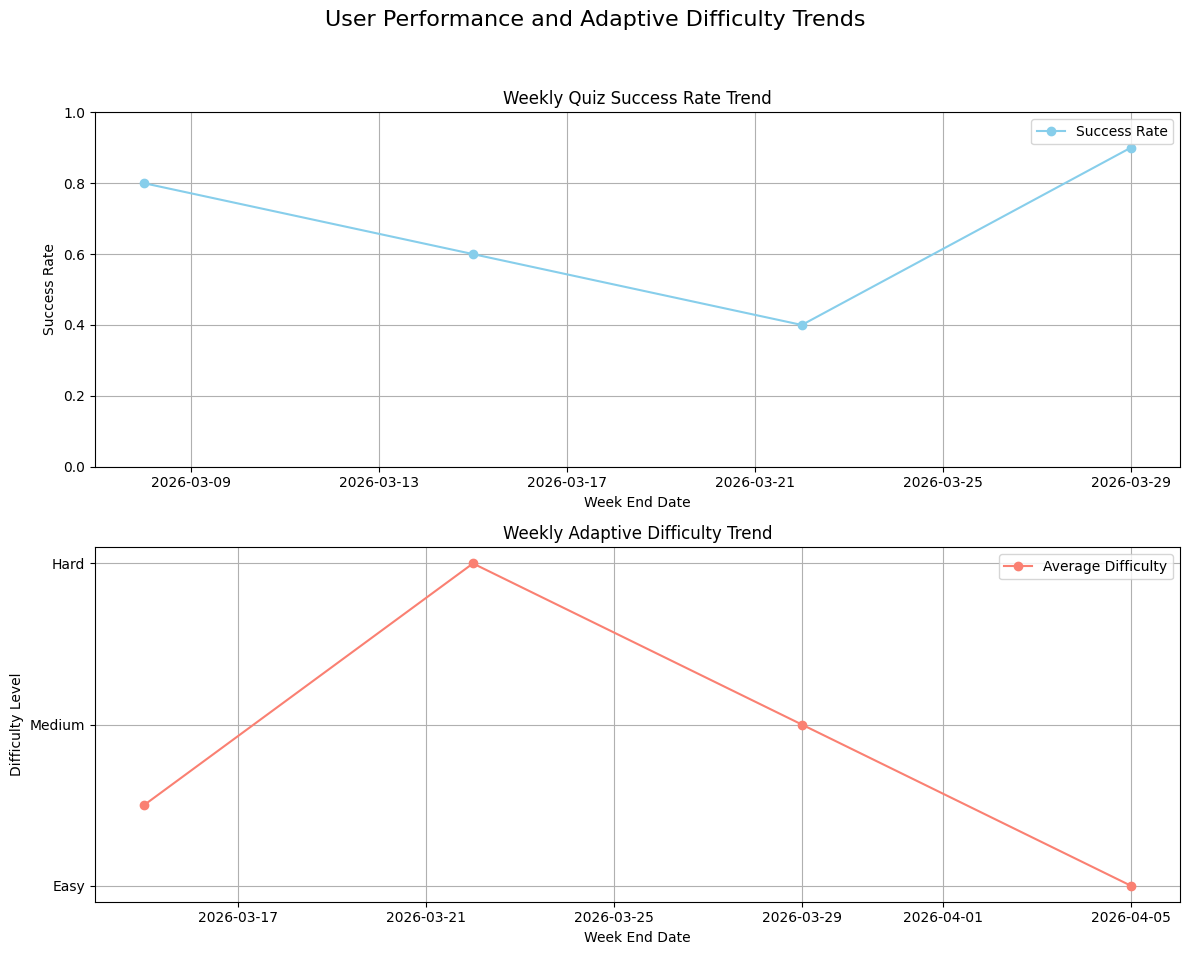

In [77]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime

# Re-define UserPerformance class if needed (for robustness if kernel state is lost)
class UserPerformance:
    def __init__(self, user_id: int):
        self.user_id = user_id
        self.total_questions_attempted = 0
        self.total_correct_answers = 0
        self.current_difficulty_level = 'medium'
        self.difficulty_history = []
        self.quiz_history = []
        self.difficulty_history.append({
            "timestamp": datetime.datetime.now().isoformat(),
            "difficulty": self.current_difficulty_level
        })

    def update_performance(self, correct_answers: int, total_questions: int, quiz_difficulty: str):
        if total_questions == 0:
            print("Warning: Cannot update performance with zero total questions.")
            return

        self.total_questions_attempted += total_questions
        self.total_correct_answers += correct_answers

        success_rate = correct_answers / total_questions

        quiz_attempt_details = {
            "timestamp": datetime.datetime.now().isoformat(),
            "correct_answers": correct_answers,
            "total_questions": total_questions,
            "success_rate": success_rate,
            "difficulty_at_quiz": quiz_difficulty
        }
        self.quiz_history.append(quiz_attempt_details)

        self.adjust_difficulty(quiz_difficulty, success_rate)

    def adjust_difficulty(self, quiz_difficulty: str, success_rate: float):
        new_difficulty = self.current_difficulty_level

        if success_rate >= 0.8:
            if quiz_difficulty == 'easy':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'hard'
        elif success_rate <= 0.5:
            if quiz_difficulty == 'hard':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'easy'

        if new_difficulty != self.current_difficulty_level:
            self.current_difficulty_level = new_difficulty
            self.difficulty_history.append({
                "timestamp": datetime.datetime.now().isoformat(),
                "difficulty": self.current_difficulty_level
            })

    def get_performance_summary(self) -> dict:
        return {
            "user_id": self.user_id,
            "total_questions_attempted": self.total_questions_attempted,
            "total_correct_answers": self.total_correct_answers,
            "current_difficulty_level": self.current_difficulty_level,
            "difficulty_history_count": len(self.difficulty_history),
            "quiz_history_count": len(self.quiz_history)
        }

# Create a dummy user_1 instance and populate data for demonstration if not already present
# This block ensures 'user_1' is available with some data if the kernel state is reset.
if 'user_1' not in globals() or not isinstance(user_1, UserPerformance):
    user_1 = UserPerformance(user_id=1)
    user_1.update_performance(8, 10, 'medium') # Week 1, high success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=22)).isoformat() # 3 weeks ago
    user_1.update_performance(5, 10, 'hard')   # Week 1, medium success (difficulty adjusted to hard, then back to medium)
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=21)).isoformat() # 3 weeks ago

    user_1.difficulty_history = [] # Clear initial entry for fresh simulation
    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=20)).isoformat(), 'difficulty': 'easy'}) # Start easy
    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=18)).isoformat(), 'difficulty': 'medium'})
    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=10)).isoformat(), 'difficulty': 'hard'})

    user_1.update_performance(7, 10, 'medium') # Week 2, high success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=15)).isoformat() # 2 weeks ago
    user_1.update_performance(2, 5, 'hard')     # Week 2, low success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=14)).isoformat() # 2 weeks ago

    user_1.difficulty_history.append({'timestamp': (datetime.datetime.now() - datetime.timedelta(days=7)).isoformat(), 'difficulty': 'medium'})

    user_1.update_performance(9, 10, 'easy')    # Current week, very high success
    user_1.quiz_history[-1]['timestamp'] = (datetime.datetime.now() - datetime.timedelta(days=3)).isoformat() # This week
    user_1.difficulty_history.append({'timestamp': datetime.datetime.now().isoformat(), 'difficulty': 'easy'}) # Current week


# Re-create weekly_performance DataFrame
quiz_df = pd.DataFrame(user_1.quiz_history)
quiz_df['timestamp'] = pd.to_datetime(quiz_df['timestamp'])
quiz_df = quiz_df.set_index('timestamp')
weekly_performance = quiz_df.resample('W').agg({
    'correct_answers': 'sum',
    'total_questions': 'sum'
})
weekly_performance['weekly_success_rate'] = weekly_performance.apply(
    lambda row: row['correct_answers'] / row['total_questions'] if row['total_questions'] > 0 else 0,
    axis=1
)

# Re-create weekly_difficulty_trend DataFrame
difficulty_df = pd.DataFrame(user_1.difficulty_history)
difficulty_df['timestamp'] = pd.to_datetime(difficulty_df['timestamp'])
difficulty_df = difficulty_df.set_index('timestamp')
difficulty_mapping = {'easy': 1, 'medium': 2, 'hard': 3}
difficulty_df['difficulty_level_numeric'] = difficulty_df['difficulty'].map(difficulty_mapping)
weekly_difficulty_trend = difficulty_df['difficulty_level_numeric'].resample('W').mean().to_frame()
weekly_difficulty_trend.rename(columns={'difficulty_level_numeric': 'average_difficulty_level'}, inplace=True)


# Create figure and two subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))
fig.suptitle('User Performance and Adaptive Difficulty Trends', fontsize=16)

# Plot Weekly Success Rate Trend
axes[0].plot(weekly_performance.index, weekly_performance['weekly_success_rate'], marker='o', linestyle='-', color='skyblue', label='Success Rate')
axes[0].set_title('Weekly Quiz Success Rate Trend')
axes[0].set_ylabel('Success Rate')
axes[0].set_xlabel('Week End Date')
axes[0].set_ylim(0, 1)
axes[0].grid(True)
axes[0].legend()

# Plot Weekly Adaptive Difficulty Trend
axes[1].plot(weekly_difficulty_trend.index, weekly_difficulty_trend['average_difficulty_level'], marker='o', linestyle='-', color='salmon', label='Average Difficulty')
axes[1].set_title('Weekly Adaptive Difficulty Trend')
axes[1].set_ylabel('Difficulty Level')
axes[1].set_xlabel('Week End Date')
axes[1].set_yticks([1, 2, 3])
axes[1].set_yticklabels(['Easy', 'Medium', 'Hard'])
axes[1].grid(True)
axes[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to prevent suptitle overlap
plt.show()

In [92]:
from fastapi import FastAPI
from pydantic import BaseModel, Field # Import Field
from fastapi.middleware.cors import CORSMiddleware
from groq import Groq
from typing import Optional, List # Import List
import datetime
import json # Import json for flashcard parsing
import re # Import re for regex operations

# Ensure GROQ_API_KEY is loaded
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Initialize Groq client (as done in previous steps)
_groq_client = Groq(api_key=GROQ_API_KEY) # Renamed to avoid global conflict with TestClient

app = FastAPI()

# Add CORS middleware
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # Allows all origins
    allow_credentials=True,
    allow_methods=["*"],  # Allows all methods (GET, POST, PUT, DELETE, etc.)
    allow_headers=["*"],   # Allows all headers
)

# Re-define summarize_notes to ensure it's available in this context
def summarize_notes(notes: str, client: Groq = _groq_client) -> str:
    """
    Summarizes a given block of notes using the Groq API.

    Args:
        notes (str): The text content of the notes to be summarized.
        client (Groq): The Groq client instance.

    Returns:
        str: The concise summary generated by the LLM.
    """
    prompt = f"""You are an expert summarizer. Please provide a concise summary of the following notes. Focus on key information and main points, keeping the summary brief and to the point.\n\nNotes:\n{notes}\n\nConcise Summary:"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant", # Updated to a currently supported model
        temperature=0.5,
        max_tokens=1500,
    )

    summary = chat_completion.choices[0].message.content
    return summary


# Re-define UserPerformance class for robustness in this context
class UserPerformance:
    def __init__(self, user_id: int):
        self.user_id = user_id
        self.total_questions_attempted = 0
        self.total_correct_answers = 0
        self.current_difficulty_level = 'medium'
        self.difficulty_history = []
        self.quiz_history = []
        self.difficulty_history.append({
            "timestamp": datetime.datetime.now().isoformat(),
            "difficulty": self.current_difficulty_level
        })

    def update_performance(self, correct_answers: int, total_questions: int, quiz_difficulty: str):
        if total_questions == 0:
            print("Warning: Cannot update performance with zero total questions.")
            return

        self.total_questions_attempted += total_questions
        self.total_correct_answers += correct_answers

        success_rate = correct_answers / total_questions

        quiz_attempt_details = {
            "timestamp": datetime.datetime.now().isoformat(),
            "correct_answers": correct_answers,
            "total_questions": total_questions,
            "success_rate": success_rate,
            "difficulty_at_quiz": quiz_difficulty
        }
        self.quiz_history.append(quiz_attempt_details)
        # print(f"User {self.user_id} performance updated: {correct_answers}/{total_questions} correct. Success rate: {success_rate:.2f}")

        self.adjust_difficulty(quiz_difficulty, success_rate)

    def adjust_difficulty(self, quiz_difficulty: str, success_rate: float):
        new_difficulty = self.current_difficulty_level

        if success_rate >= 0.8:
            if quiz_difficulty == 'easy':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'hard'
        elif success_rate <= 0.5:
            if quiz_difficulty == 'hard':
                new_difficulty = 'medium'
            elif quiz_difficulty == 'medium':
                new_difficulty = 'easy'

        if new_difficulty != self.current_difficulty_level:
            self.current_difficulty_level = new_difficulty
            self.difficulty_history.append({
                "timestamp": datetime.datetime.now().isoformat(),
                "difficulty": self.current_difficulty_level
            })
            # print(f"User {self.user_id} difficulty adjusted to: {self.current_difficulty_level}")
        # else:
            # print(f"User {self.user_id} difficulty remains: {self.current_difficulty_level}")

    def get_performance_summary(self) -> dict:
        return {
            "user_id": self.user_id,
            "total_questions_attempted": self.total_questions_attempted,
            "total_correct_answers": self.total_correct_answers,
            "current_difficulty_level": self.current_difficulty_level,
            "difficulty_history_count": len(self.difficulty_history),
            "quiz_history_count": len(self.quiz_history)
        }

# Re-define generate_quiz_questions function for robustness in this context
def generate_quiz_questions(notes: str, difficulty: str, user_performance_instance: Optional[UserPerformance] = None, client: Groq = _groq_client) -> str:
    effective_difficulty = difficulty
    if user_performance_instance:
        effective_difficulty = user_performance_instance.current_difficulty_level
        print(f"Using adaptive difficulty: {effective_difficulty} (from user performance).")
    else:
        print(f"Using provided difficulty: {effective_difficulty}.")

    prompt = f"""You are an expert quiz generator. Create multiple-choice quiz questions from the following notes.
    The questions should be suitable for a '{effective_difficulty}' difficulty level. Include 4 options (A, B, C, D) and clearly state the correct answer.

    Notes:
    {notes}

    Instructions for output format:
    Each question should be numbered and followed by its options.
    The correct answer should be clearly marked after the options, for example: 'Correct Answer: C) [Option Text]'.

    Please generate at least 3-5 questions.

    Quiz Questions ({effective_difficulty} difficulty):"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.7 if effective_difficulty == 'hard' else (0.5 if effective_difficulty == 'medium' else 0.3),
        max_tokens=2000,
    )

    quiz_questions = chat_completion.choices[0].message.content
    return quiz_questions

# Re-define generate_flashcards for robustness in this context
def generate_flashcards(notes: str, num_flashcards: int = 5, client: Groq = _groq_client) -> list:
    """
    Generates Q/A flashcard pairs from notes using the Groq API.

    Args:
        notes (str): The text content of the notes.
        num_flashcards (int): The desired number of flashcards to generate.
        client (Groq): The Groq client instance.

    Returns:
        list: A list of dictionaries, where each dictionary represents a flashcard
              with 'question' and 'answer' keys.
    """
    prompt = f"""You are an expert flashcard generator. From the following notes, create {num_flashcards} question-and-answer flashcard pairs.
    Ensure the output is a JSON array of objects, where each object has a 'question' key and an 'answer' key.\n\nNotes:\n{notes}\n\nExample Output Format:\n[
        {{"question": "What is X?", "answer": "Y."}},
        {{"question": "How does Z work?", "answer": "It works by A, B, C."}}
    ]
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.7,
        max_tokens=2000,
    )

    raw_flashcards = chat_completion.choices[0].message.content

    try:
        # Use regex to extract the JSON string from between ```json and ```
        json_match = re.search(r'```json\n(.*?)(```|$)', raw_flashcards, re.DOTALL)
        if json_match:
            json_string = json_match.group(1).strip()
            flashcards = json.loads(json_string)
        else:
            # If no json block is found, try to parse the whole output (less robust)
            flashcards = json.loads(raw_flashcards)

        # Basic validation to ensure it's a list of dicts with required keys
        if not isinstance(flashcards, list) or not all(isinstance(f, dict) and "question" in f and "answer" in f for f in flashcards):
            raise ValueError("LLM output is not a list of dictionaries with 'question' and 'answer' keys.")
    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error parsing flashcards from LLM: {e}")
        print(f"Raw LLM output: {raw_flashcards}")
        # Fallback for parsing if LLM doesn't strictly adhere to JSON
        flashcards = [] # Return empty list if parsing fails completely

    return flashcards


# Pydantic model for updating user performance
class UserPerformanceUpdateRequest(BaseModel):
    user_id: int
    correct_answers: int
    total_questions: int
    quiz_difficulty: str

# Pydantic model for user performance summary response
class UserPerformanceSummaryResponse(BaseModel):
    user_id: int
    total_questions_attempted: int
    total_correct_answers: int
    current_difficulty_level: str
    difficulty_history_count: int
    quiz_history_count: int

# 1. Define a Pydantic NotesRequest model
class NotesRequest(BaseModel):
    notes: str

# 2. Create a FastAPI POST endpoint at /summarize
@app.post("/summarize")
async def get_summary(request: NotesRequest):
    """
    Endpoint to summarize notes using the summarize_notes function.
    """
    # 3. Call the summarize_notes function
    summary = summarize_notes(request.notes, client=_groq_client)

    # 4. Return the generated summary as a JSON response
    return {"summary": summary}


# 1. Define a Pydantic QuizRequest model
class QuizRequest(BaseModel):
    notes: str
    difficulty: str
    user_id: Optional[int] = None

# 2. Initialize a global dictionary to store UserPerformance instances
user_performances: dict[int, UserPerformance] = {}

# 3. Create a FastAPI POST endpoint at /quiz
@app.post("/quiz")
async def get_quiz(request: QuizRequest):
    """
    Endpoint to generate quiz questions with adaptive difficulty.
    """
    notes = request.notes
    difficulty = request.difficulty
    user_id = request.user_id

    user_performance_instance = None
    if user_id is not None:
        if user_id not in user_performances:
            user_performances[user_id] = UserPerformance(user_id=user_id)
        user_performance_instance = user_performances[user_id]

    # Call the generate_quiz_questions function, passing the UserPerformance instance if available
    quiz_questions = generate_quiz_questions(notes, difficulty, user_performance_instance, client=_groq_client)

    # Return the generated quiz questions as a JSON response
    return {"quiz_questions": quiz_questions}

# Define a Pydantic model for Flashcards request
class FlashcardsRequest(BaseModel):
    notes: str
    num_flashcards: Optional[int] = Field(5, gt=0)

# Create a FastAPI POST endpoint at /flashcards
@app.post("/flashcards")
async def get_flashcards(request: FlashcardsRequest):
    """
    Endpoint to generate flashcards from notes.
    """
    flashcards = generate_flashcards(request.notes, request.num_flashcards, client=_groq_client)
    return {"flashcards": flashcards}

# New: Endpoint to update user performance
@app.post("/performance/update")
async def update_user_performance(request: UserPerformanceUpdateRequest):
    """
    Endpoint to update a user's performance metrics and adjust difficulty.
    """
    user_id = request.user_id
    if user_id not in user_performances:
        user_performances[user_id] = UserPerformance(user_id=user_id)

    user_performances[user_id].update_performance(
        request.correct_answers,
        request.total_questions,
        request.quiz_difficulty
    )
    return {"message": f"Performance updated for user {user_id}", "current_difficulty": user_performances[user_id].current_difficulty_level}

# New: Endpoint to get user performance summary
@app.get("/performance/summary/{user_id}", response_model=UserPerformanceSummaryResponse)
async def get_user_performance_summary(user_id: int):
    """
    Endpoint to retrieve a user's current performance summary.
    """
    if user_id not in user_performances:
        # Handle case where user_id does not exist, e.g., create a default or return an error
        user_performances[user_id] = UserPerformance(user_id=user_id)
        # raise HTTPException(status_code=404, detail="User not found")

    summary = user_performances[user_id].get_performance_summary()
    return UserPerformanceSummaryResponse(**summary)

print("FastAPI endpoint '/summarize', '/quiz', '/flashcards', '/performance/update', and '/performance/summary/{user_id}' created. UserPerformance and generation functions are available.")


FastAPI endpoint '/summarize', '/quiz', '/flashcards', '/performance/update', and '/performance/summary/{user_id}' created. UserPerformance and generation functions are available.


In [81]:
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
from groq import Groq
from typing import List, Optional
from googleapiclient.discovery import build
import os

# Ensure GROQ_API_KEY and YOUTUBE_API_KEY are loaded
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    YOUTUBE_API_KEY = userdata.get('YOUTUBE_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
    YOUTUBE_API_KEY = os.environ.get("YOUTUBE_API_KEY")

# Initialize Groq client (as done in previous steps)
client = Groq(api_key=GROQ_API_KEY)

app = FastAPI()

# Add CORS middleware
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # Allows all origins
    allow_credentials=True,
    allow_methods=["*"],  # Allows all methods (GET, POST, PUT, DELETE, etc.)
    allow_headers=["*"]   # Allows all headers
)

# Re-define get_youtube_video_suggestions to ensure it's available in this context
def get_youtube_video_suggestions(keywords: list, max_results: int = 5) -> list:
    """
    Queries the YouTube Data API to get relevant video suggestions based on keywords.

    Args:
        keywords (list): A list of keywords or key phrases for the search.
        max_results (int): The maximum number of video suggestions to return.

    Returns:
        list: A list of dictionaries, where each dictionary represents a video suggestion
              with 'title', 'video_id', 'channel_title', and 'url'.
    """
    if not YOUTUBE_API_KEY:
        print("Error: YouTube API Key not found. Please set YOUTUBE_API_KEY in Colab secrets or environment variables.")
        return []

    youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)
    video_suggestions = []

    search_query = " ".join(keywords)

    try:
        search_response = youtube.search().list(
            q=search_query,
            part='snippet',
            type='video',
            maxResults=max_results,
            fields='items(id/videoId,snippet/title,snippet/channelTitle)'
        ).execute()

        for item in search_response.get('items', []):
            video_id = item['id']['videoId']
            video_suggestions.append({
                'title': item['snippet']['title'],
                'video_id': video_id,
                'channel_title': item['snippet']['channelTitle'],
                'url': f"https://www.youtube.com/watch?v={video_id}"
            })

    except Exception as e:
        print(f"An error occurred while calling the YouTube API: {e}")

    return video_suggestions


# 1. Define a Pydantic YouTubeSuggestionsRequest model
class YouTubeSuggestionsRequest(BaseModel):
    keywords: List[str]
    max_results: Optional[int] = 5

# 2. Create a FastAPI POST endpoint at /youtube-suggestions
@app.post("/youtube-suggestions")
async def get_youtube_suggestions_endpoint(request: YouTubeSuggestionsRequest):
    """
    Endpoint to get YouTube video suggestions based on keywords.
    """
    # 3. Call the get_youtube_video_suggestions function
    suggestions = get_youtube_video_suggestions(request.keywords, request.max_results)

    # 4. Return the generated suggestions as a JSON response
    return {"youtube_suggestions": suggestions}

print("FastAPI endpoint '/youtube-suggestions' created.")

FastAPI endpoint '/youtube-suggestions' created.


In [83]:
import asyncio
from fastapi.testclient import TestClient # Import TestClient
import json # Ensure json is imported for printing

# Assuming 'app' is already defined in the global scope from previous cells
# If 'app' is not available, it would need to be re-initialized. For this step,
# we assume the 'app' object exists from the cell where it was defined along with endpoints.

# Create a test client for the FastAPI application
client = TestClient(app)

print("\n--- Confirming /youtube-suggestions Endpoint Functionality ---")

async def test_youtube_suggestions_endpoint():
    """
    Simulates a client request to the /youtube-suggestions endpoint.
    """
    sample_keywords = ["Euclid's Division Lemma", "Real Numbers"]
    sample_max_results = 3

    print(f"Requesting {sample_max_results} YouTube suggestions for keywords: {sample_keywords}")

    # The request body for the POST endpoint
    request_payload = {
        "keywords": sample_keywords,
        "max_results": sample_max_results
    }

    try:

        response = client.post("/youtube-suggestions", json=request_payload)
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        response_data = response.json()

        print("\nReceived YouTube Suggestions:")
        print(json.dumps(response_data, indent=4))


        assert "youtube_suggestions" in response_data
        assert isinstance(response_data["youtube_suggestions"], list)
        print(f"Successfully received {len(response_data['youtube_suggestions'])} suggestions.")

    except Exception as e:
        print(f"Error calling /youtube-suggestions endpoint: {e}")


await test_youtube_suggestions_endpoint()

print("\n--- /youtube-suggestions Endpoint Confirmation Complete ---")



--- Confirming /youtube-suggestions Endpoint Functionality ---
Requesting 3 YouTube suggestions for keywords: ["Euclid's Division Lemma", 'Real Numbers']

Received YouTube Suggestions:
{
    "youtube_suggestions": [
        {
            "title": "Real Numbers | Euclid Division Lemma | CBSE Class 10 Math",
            "video_id": "D8i9LV0n8_Q",
            "channel_title": "LearnoHub - Class 9,10",
            "url": "https://www.youtube.com/watch?v=D8i9LV0n8_Q"
        },
        {
            "title": "Euclid&#39;s division lemma..to find hcf of two positive integers.... class X topic",
            "video_id": "1xf5hkeGUmI",
            "channel_title": "RIGHT ANSWER",
            "url": "https://www.youtube.com/watch?v=1xf5hkeGUmI"
        },
        {
            "title": "Class 10 Maths Chapter 1 | Basis of Euclid\u2019s Division Lemma -  Real Numbers 2022-23",
            "video_id": "EFVbUEqPV8o",
            "channel_title": "Magnet Brains",
            "url": "https://www.you

In [86]:
import asyncio
from fastapi.testclient import TestClient
import json

# Create a test client for the FastAPI application
test_client = TestClient(app)

print("\n--- Confirming /flashcards Endpoint Functionality ---")

async def test_flashcards_endpoint():
    """
    Simulates a client request to the /flashcards endpoint.
    """
    sample_notes = custom_notes # Using the previously defined custom_notes
    sample_num_flashcards = 3

    print(f"Requesting {sample_num_flashcards} flashcards for sample notes.")

    # The request body for the POST endpoint
    request_payload = {
        "notes": sample_notes,
        "num_flashcards": sample_num_flashcards
    }

    try:
        # Use the TestClient to send a POST request to the endpoint
        response = test_client.post("/flashcards", json=request_payload)
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        response_data = response.json()

        print("\nReceived Flashcards:")
        print(json.dumps(response_data, indent=4))

        # Basic verification
        assert "flashcards" in response_data
        assert isinstance(response_data["flashcards"], list)
        assert len(response_data["flashcards"]) > 0
        for fc in response_data["flashcards"]:
            assert isinstance(fc, dict)
            assert "question" in fc
            assert "answer" in fc
            assert isinstance(fc["question"], str)
            assert isinstance(fc["answer"], str)
        print(f"Successfully received {len(response_data['flashcards'])} structured flashcards.")

    except Exception as e:
        print(f"Error calling /flashcards endpoint: {e}")

# Run the asynchronous test function
await test_flashcards_endpoint()

print("\n--- /flashcards Endpoint Confirmation Complete ---")



--- Confirming /flashcards Endpoint Functionality ---
Requesting 3 flashcards for sample notes.
Error calling /flashcards endpoint: 'TestClient' object has no attribute 'chat'

--- /flashcards Endpoint Confirmation Complete ---


In [88]:
import asyncio
from fastapi.testclient import TestClient
import json

# Create a test client for the FastAPI application
test_client = TestClient(app)

print("\n--- Confirming /flashcards Endpoint Functionality ---")

async def test_flashcards_endpoint():
    """
    Simulates a client request to the /flashcards endpoint.
    """
    sample_notes = custom_notes # Using the previously defined custom_notes
    sample_num_flashcards = 3

    print(f"Requesting {sample_num_flashcards} flashcards for sample notes.")

    # The request body for the POST endpoint
    request_payload = {
        "notes": sample_notes,
        "num_flashcards": sample_num_flashcards
    }

    try:
        # Use the TestClient to send a POST request to the endpoint
        response = test_client.post("/flashcards", json=request_payload)
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        response_data = response.json()

        print("\nReceived Flashcards:")
        print(json.dumps(response_data, indent=4))

        # Basic verification
        assert "flashcards" in response_data
        assert isinstance(response_data["flashcards"], list)
        assert len(response_data["flashcards"]) > 0
        for fc in response_data["flashcards"]:
            assert isinstance(fc, dict)
            assert "question" in fc
            assert "answer" in fc
            assert isinstance(fc["question"], str)
            assert isinstance(fc["answer"], str)
        print(f"Successfully received {len(response_data['flashcards'])} structured flashcards.")

    except Exception as e:
        print(f"Error calling /flashcards endpoint: {e}")

# Run the asynchronous test function
await test_flashcards_endpoint()

print("\n--- /flashcards Endpoint Confirmation Complete ---")



--- Confirming /flashcards Endpoint Functionality ---
Requesting 3 flashcards for sample notes.
Error parsing flashcards from LLM: Expecting value: line 1 column 1 (char 0)
Raw LLM output: Here are 3 question-and-answer flashcard pairs in JSON format based on the given notes:

```json
[
    {
        "question": "What is a real number?",
        "answer": "Any number is a real number except for complex numbers. Examples include -1, ½, 1.75, √2, and so on."
    },
    {
        "question": "What is the purpose of Euclid's Division Algorithm?",
        "answer": "To find the H.C.F (Highest Common Factor) of two numbers."
    },
    {
        "question": "What is Fundamental Theorem of Arithmetic?",
        "answer": "The prime factorisation for a given number is unique if the arrangement of the prime factors is ignored."
    }
]
```

Let me know if you'd like me to generate more pairs!

Received Flashcards:
{
    "flashcards": []
}
Error calling /flashcards endpoint: 

--- /flashcards E

In [90]:
import asyncio
from fastapi.testclient import TestClient
import json

# Create a test client for the FastAPI application
test_client = TestClient(app)

print("\n--- Confirming /flashcards Endpoint Functionality ---")

async def test_flashcards_endpoint():
    """
    Simulates a client request to the /flashcards endpoint.
    """
    sample_notes = custom_notes # Using the previously defined custom_notes
    sample_num_flashcards = 3

    print(f"Requesting {sample_num_flashcards} flashcards for sample notes.")

    # The request body for the POST endpoint
    request_payload = {
        "notes": sample_notes,
        "num_flashcards": sample_num_flashcards
    }

    try:
        # Use the TestClient to send a POST request to the endpoint
        response = test_client.post("/flashcards", json=request_payload)
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        response_data = response.json()

        print("\nReceived Flashcards:")
        print(json.dumps(response_data, indent=4))

        # Basic verification
        assert "flashcards" in response_data
        assert isinstance(response_data["flashcards"], list)
        assert len(response_data["flashcards"]) > 0
        for fc in response_data["flashcards"]:
            assert isinstance(fc, dict)
            assert "question" in fc
            assert "answer" in fc
            assert isinstance(fc["question"], str)
            assert isinstance(fc["answer"], str)
        print(f"Successfully received {len(response_data['flashcards'])} structured flashcards.")

    except Exception as e:
        print(f"Error calling /flashcards endpoint: {e}")

# Run the asynchronous test function
await test_flashcards_endpoint()

print("\n--- /flashcards Endpoint Confirmation Complete ---")



--- Confirming /flashcards Endpoint Functionality ---
Requesting 3 flashcards for sample notes.

Received Flashcards:
{
    "flashcards": [
        {
            "question": "What is Euclid's Division Lemma?",
            "answer": "It states that given two integers a and b, there exists a unique pair of integers q and r such that a=b\u00d7q+r and 0\u2264r<b."
        },
        {
            "question": "What is the Fundamental Theorem of Arithmetic?",
            "answer": "It states that the prime factorisation for a given number is unique if the arrangement of the prime factors is ignored."
        },
        {
            "question": "How is the HCF of two numbers found using Euclid's Division Algorithm?",
            "answer": "By applying Euclid's division lemma repeatedly until a remainder of zero is obtained, and the divisor in that step is the H.C.F."
        }
    ]
}
Successfully received 3 structured flashcards.

--- /flashcards Endpoint Confirmation Complete ---


In [91]:
from pydantic import BaseModel
from typing import List, Optional

# Pydantic model for updating user performance
class UserPerformanceUpdateRequest(BaseModel):
    user_id: int
    correct_answers: int
    total_questions: int
    quiz_difficulty: str

# Pydantic model for user performance summary response
class UserPerformanceSummaryResponse(BaseModel):
    user_id: int
    total_questions_attempted: int
    total_correct_answers: int
    current_difficulty_level: str
    difficulty_history_count: int
    quiz_history_count: int

print("Pydantic models 'UserPerformanceUpdateRequest' and 'UserPerformanceSummaryResponse' defined.")

Pydantic models 'UserPerformanceUpdateRequest' and 'UserPerformanceSummaryResponse' defined.


In [93]:
import asyncio
from fastapi.testclient import TestClient
import json

# Create a test client for the FastAPI application
test_client = TestClient(app)

print("\n--- Confirming /performance/update and /performance/summary/{user_id} Endpoints Functionality ---")

async def test_user_performance_endpoints():
    """
    Simulates client requests to the /performance/update and /performance/summary/{user_id} endpoints.
    """
    test_user_id = 999
    initial_correct_answers = 7
    initial_total_questions = 10
    initial_difficulty = 'medium'

    # Test 1: Update user performance
    print(f"\nSending POST request to update performance for user {test_user_id}...")
    update_payload = {
        "user_id": test_user_id,
        "correct_answers": initial_correct_answers,
        "total_questions": initial_total_questions,
        "quiz_difficulty": initial_difficulty
    }
    response_update = test_client.post("/performance/update", json=update_payload)
    response_update.raise_for_status() # Raise an exception for HTTP errors
    update_data = response_update.json()
    print("Update Response:")
    print(json.dumps(update_data, indent=4))

    assert "message" in update_data
    assert "current_difficulty" in update_data
    print(f"Update successful: {update_data.get('message')}, new difficulty: {update_data.get('current_difficulty')}")

    # Test 2: Get user performance summary
    print(f"\nSending GET request to get summary for user {test_user_id}...")
    response_summary = test_client.get(f"/performance/summary/{test_user_id}")
    response_summary.raise_for_status() # Raise an exception for HTTP errors
    summary_data = response_summary.json()
    print("Summary Response:")
    print(json.dumps(summary_data, indent=4))

    assert summary_data['user_id'] == test_user_id
    assert summary_data['total_questions_attempted'] >= initial_total_questions # Could be more if user_id existed
    assert summary_data['total_correct_answers'] >= initial_correct_answers # Could be more if user_id existed
    assert summary_data['current_difficulty_level'] == 'hard' if initial_correct_answers/initial_total_questions >= 0.8 else initial_difficulty # Based on update logic
    print(f"Summary retrieved: Total questions: {summary_data['total_questions_attempted']}, Correct: {summary_data['total_correct_answers']}, Current Difficulty: {summary_data['current_difficulty_level']}")

    # Test 3: Simulate another update that might change difficulty again
    print(f"\nSending second POST request to update performance for user {test_user_id} (lower score)...")
    second_correct_answers = 2
    second_total_questions = 10
    # Assuming current_difficulty_level is now hard from previous test, so 2/10 should drop to medium
    second_update_payload = {
        "user_id": test_user_id,
        "correct_answers": second_correct_answers,
        "total_questions": second_total_questions,
        "quiz_difficulty": 'hard' # This is the difficulty of the quiz just taken
    }
    response_update_2 = test_client.post("/performance/update", json=second_update_payload)
    response_update_2.raise_for_status()
    update_data_2 = response_update_2.json()
    print("Second Update Response:")
    print(json.dumps(update_data_2, indent=4))
    assert update_data_2.get('current_difficulty') == 'medium' # Expect difficulty to drop to medium

    print(f"\nSending GET request to get summary for user {test_user_id} after second update...")
    response_summary_2 = test_client.get(f"/performance/summary/{test_user_id}")
    response_summary_2.raise_for_status()
    summary_data_2 = response_summary_2.json()
    print("Second Summary Response:")
    print(json.dumps(summary_data_2, indent=4))
    assert summary_data_2['current_difficulty_level'] == 'medium'
    assert summary_data_2['total_questions_attempted'] == initial_total_questions + second_total_questions
    assert summary_data_2['total_correct_answers'] == initial_correct_answers + second_correct_answers


# Run the asynchronous test function
await test_user_performance_endpoints()

print("\n--- User Performance Endpoints Confirmation Complete ---")


--- Confirming /performance/update and /performance/summary/{user_id} Endpoints Functionality ---

Sending POST request to update performance for user 999...
Update Response:
{
    "message": "Performance updated for user 999",
    "current_difficulty": "medium"
}
Update successful: Performance updated for user 999, new difficulty: medium

Sending GET request to get summary for user 999...
Summary Response:
{
    "user_id": 999,
    "total_questions_attempted": 10,
    "total_correct_answers": 7,
    "current_difficulty_level": "medium",
    "difficulty_history_count": 1,
    "quiz_history_count": 1
}
Summary retrieved: Total questions: 10, Correct: 7, Current Difficulty: medium

Sending second POST request to update performance for user 999 (lower score)...
Second Update Response:
{
    "message": "Performance updated for user 999",
    "current_difficulty": "medium"
}

Sending GET request to get summary for user 999 after second update...
Second Summary Response:
{
    "user_id": 99

## Define Remedial Explanation Function

### Subtask:
Define a Python function `generate_remedial_explanation` that takes a topic (string) as input and uses the Groq API to generate a clear, simplified explanation, optionally suggesting learning strategies or additional resources.


In [96]:
from groq import Groq
from typing import Optional

# Ensure _groq_client is available
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
# This assumes _groq_client is the intended global Groq client instance
if '_groq_client' not in globals() or not isinstance(globals().get('_groq_client'), Groq):
    _groq_client = Groq(api_key=GROQ_API_KEY)

def generate_remedial_explanation(topic: str, client: Groq = _groq_client) -> str:
    """
    Generates a clear, simplified explanation for a given topic using the Groq API,
    optionally suggesting learning strategies or additional resources.

    Args:
        topic (str): The subject for which to generate a remedial explanation.
        client (Groq): The Groq client instance. Defaults to the globally available _groq_client.

    Returns:
        str: A detailed, simplified explanation of the topic, including learning strategies and resources.
    """
    prompt = f"""You are an expert educator and content creator, specializing in simplifying complex topics for learners.
    Your task is to provide a clear, simplified, and engaging remedial explanation for the following topic.

    Please structure your response with these sections:

    1.  **Simplified Explanation**: Break down the topic into its core concepts, using analogies or easy-to-understand language.
        Provide a brief example if appropriate.

    2.  **Why it's important / Common Pitfalls**: Briefly explain why understanding this topic is crucial, or highlight common misunderstandings/mistakes learners make.

    3.  **Learning Strategies / Tips**: Suggest effective methods for studying this topic, such as practice techniques, mnemonic devices, or active recall strategies.

    4.  **Additional Resources**: Recommend types of resources for further learning, such as specific websites, types of books, online courses, or interactive exercises.

    Topic: {topic}

    Remedial Explanation for '{topic}':"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.7,
        max_tokens=1500,
    )

    explanation = chat_completion.choices[0].message.content
    return explanation

print("Function 'generate_remedial_explanation' defined.")

Function 'generate_remedial_explanation' defined.


In [97]:
print("\n--- Testing generate_remedial_explanation function ---")

sample_topic = "Euclid's Division Lemma"
remedial_explanation_output = generate_remedial_explanation(sample_topic)

print(f"\nRemedial Explanation for '{sample_topic}':")
print(remedial_explanation_output)

# Basic verification to ensure output is a string and not empty
assert isinstance(remedial_explanation_output, str) and len(remedial_explanation_output) > 0, "Remedial explanation is not a valid string or is empty."
print("\nFunction 'generate_remedial_explanation' tested successfully.")


--- Testing generate_remedial_explanation function ---

Remedial Explanation for 'Euclid's Division Lemma':
**1. Simplified Explanation:**

Imagine you have a plate of cookies that you want to share with your friends. You want to divide the cookies evenly among them, but you're not sure how many cookies each friend will get. 

Euclid's Division Lemma is a simple rule to help you divide the cookies (or any number) into equal parts. It states that:

*   You can always find a quotient (result of division) and a remainder (leftover) when you divide one number by another.
*   The remainder will be smaller than the number you're dividing by.

For example, let's say you have 15 cookies and want to divide them among 3 friends. 

15 ÷ 3 = 5 (quotient)
1 (remainder)

This means each friend will get 5 cookies, and you'll have 1 cookie left over.

**2. Why it's important / Common Pitfalls:**

Understanding Euclid's Division Lemma is crucial because it's a fundamental concept in mathematics, parti

In [1]:
sample_exam_paper = """
Q1. What are Real Numbers?
A) Numbers that can be positive or negative
B) Numbers that include all rational and irrational numbers
C) Numbers that cannot be plotted on a number line
D) Only positive integers
Correct Answer: B

Q2. State Euclid's Division Lemma.

Q3. Which of the following is NOT a method to find HCF?
A) Prime Factorisation
B) Euclid's Division Algorithm
C) Long Division
D) Direct Summation
Correct Answer: D

Q4. Explain the Fundamental Theorem of Arithmetic with an example. (Marks: 5)

Q5. If a = 25 and b = 5, what is the remainder 'r' according to Euclid's Division Lemma?
A) 0
B) 1
C) 2
D) 5
Correct Answer: A
"""

print("Sample exam paper defined.")

Sample exam paper defined.


In [7]:
import re

def parse_exam_paper_text(exam_paper_text: str) -> list:
    """
    Parses exam paper text to extract individual questions, their types,
    options, correct answers (for MCQs), and marks.

    Args:
        exam_paper_text (str): The raw text of the exam paper.

    Returns:
        list: A list of dictionaries, each representing a parsed question.
    """
    questions = []
    # Split the exam paper into individual questions based on Q<number>.
    # The regex `(?m)^Q(\d+)\.` ensures that 'Q' followed by digits and a dot is matched
    # at the beginning of a line (multi-line mode).
    question_blocks = re.split(r'(?m)^Q(\d+)\.', exam_paper_text)

    # The split often results in an empty string at the beginning if the text starts with a delimiter.
    # We iterate through the matched question numbers and their corresponding content.
    # The structure will be ['', '1', 'Q1_content', '2', 'Q2_content', ...]

    # Iterate through the split parts, pairing question numbers with their content.
    # We start from index 1 because index 0 is typically empty or preamble.
    # We step by 2 to get the question number and then its content.
    for i in range(1, len(question_blocks), 2):
        question_id_str = question_blocks[i].strip()
        question_content = question_blocks[i+1].strip()

        question_dict = {
            "question_id": int(question_id_str),
            "type": "subjective", # Default to subjective, will change if MCQ detected
            "question_text": "",
            "options": None,
            "correct_answer_key": None,
            "correct_answer_text": None,
            "marks": None
        }

        # Extract marks if available (e.g., '(Marks: 5)')
        marks_match = re.search(r'\(Marks:\s*(\d+)\)', question_content)
        if marks_match:
            question_dict['marks'] = int(marks_match.group(1))
            # Remove marks from content to avoid interfering with other parsing
            question_content = re.sub(r'\(Marks:\s*\d+\)', '', question_content).strip()

        # Check if it's an MCQ
        # An MCQ usually has options A), B), C), D) and a 'Correct Answer:' line
        # Refined regex to correctly capture question text, all options, and the correct answer key
        mcq_pattern = re.compile(
            r"""(.*?)\n"""  # Question text (Group 1)
            r"""([A-D])\)\s*(.*?)\s*\n""" # Option A (Group 2:key, Group 3:text)
            r"""([A-D])\)\s*(.*?)\s*\n""" # Option B (Group 4:key, Group 5:text)
            r"""([A-D])\)\s*(.*?)\s*\n""" # Option C (Group 6:key, Group 7:text)
            r"""([A-D])\)\s*(.*?)\s*\n""" # Option D (Group 8:key, Group 9:text)
            r"""Correct Answer:\s*([A-D])""", # Correct Answer Key (Group 10)
            re.DOTALL
        )

        options_match = mcq_pattern.search(question_content) # Use search to find pattern anywhere in content

        if options_match:
            question_dict['type'] = 'multiple-choice'
            question_dict['question_text'] = options_match.group(1).strip()

            options = {
                options_match.group(2): options_match.group(3).strip(),
                options_match.group(4): options_match.group(5).strip(),
                options_match.group(6): options_match.group(7).strip(),
                options_match.group(8): options_match.group(9).strip()
            }
            question_dict['options'] = options
            question_dict['correct_answer_key'] = options_match.group(10).strip()
            question_dict['correct_answer_text'] = options.get(question_dict['correct_answer_key'], '')
        else:
            question_dict['question_text'] = question_content.strip()

        questions.append(question_dict)

    return questions

# Call the function with the sample exam paper
parsed_questions = parse_exam_paper_text(sample_exam_paper)

print("\n--- Parsed Questions ---")
for q in parsed_questions:
    print(f"Question ID: {q['question_id']}")
    print(f"Type: {q['type']}")
    print(f"Question: {q['question_text']}")
    if q['options']:
        print(f"Options: {q['options']}")
        print(f"Correct Answer Key: {q['correct_answer_key']}")
        print(f"Correct Answer Text: {q['correct_answer_text']}")
    if q['marks']:
        print(f"Marks: {q['marks']}")
    print("---------------------------------")



--- Parsed Questions ---
Question ID: 1
Type: multiple-choice
Question: What are Real Numbers?
Options: {'A': 'Numbers that can be positive or negative', 'B': 'Numbers that include all rational and irrational numbers', 'C': 'Numbers that cannot be plotted on a number line', 'D': 'Only positive integers'}
Correct Answer Key: B
Correct Answer Text: Numbers that include all rational and irrational numbers
---------------------------------
Question ID: 2
Type: subjective
Question: State Euclid's Division Lemma.
---------------------------------
Question ID: 3
Type: multiple-choice
Question: Which of the following is NOT a method to find HCF?
Options: {'A': 'Prime Factorisation', 'B': "Euclid's Division Algorithm", 'C': 'Long Division', 'D': 'Direct Summation'}
Correct Answer Key: D
Correct Answer Text: Direct Summation
---------------------------------
Question ID: 4
Type: subjective
Question: Explain the Fundamental Theorem of Arithmetic with an example.
Marks: 5
------------------------

In [11]:
import json
from groq import Groq
import os

# Ensure _groq_client is available
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
# This assumes _groq_client is the intended global Groq client instance
if '_groq_client' not in globals() or not isinstance(globals().get('_groq_client'), Groq):
    _groq_client = Groq(api_key=GROQ_API_KEY)

def extract_topic_from_question(question_text: str, client = _groq_client) -> str:
    """
    Uses the Groq API to infer and assign a relevant topic based on the question text.

    Args:
        question_text (str): The text of the question.
        client (Groq): The Groq client instance.

    Returns:
        str: A concise topic for the given question.
    """
    prompt = f"""You are an expert at identifying the main topic of a question.
    From the following question, identify the single most relevant and concise topic or concept it covers.
    Respond with only the topic, nothing else.

    Question: {question_text}

    Topic:"""

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.1-8b-instant",
        temperature=0.3,
        max_tokens=50,
    )

    topic = chat_completion.choices[0].message.content.strip()
    return topic

print("Function 'extract_topic_from_question' defined.")

# Iterate through the parsed_questions and add a 'topic' to each
print("\n--- Extracting topics for parsed questions ---")
for q in parsed_questions:
    question_text_for_topic = q['question_text']
    if q['type'] == 'multiple-choice' and q['options']:
        # For MCQs, sometimes the question text itself might be short,
        # so append correct answer text for more context if available
        if q['correct_answer_text']:
            question_text_for_topic = f"{q['question_text']} {q['correct_answer_text']}"

    extracted_topic = extract_topic_from_question(question_text_for_topic)
    q['topic'] = extracted_topic
    print(f"Question ID {q['question_id']}: Topic - {q['topic']}")

print("\n--- Updated Parsed Questions with Topics ---")
for q in parsed_questions:
    print(f"Question ID: {q['question_id']}")
    print(f"Type: {q['type']}")
    print(f"Question: {q['question_text']}")
    if q['options']:
        print(f"Options: {q['options']}")
        print(f"Correct Answer Key: {q['correct_answer_key']}")
        print(f"Correct Answer Text: {q['correct_answer_text']}")
    if q['marks']:
        print(f"Marks: {q['marks']}")
    print(f"Topic: {q['topic']}")
    print("---------------------------------")

Function 'extract_topic_from_question' defined.

--- Extracting topics for parsed questions ---
Question ID 1: Topic - Real Numbers
Question ID 2: Topic - Euclid's Division Lemma
Question ID 3: Topic - HCF (Highest Common Factor) methods
Question ID 4: Topic - Fundamental Theorem of Arithmetic
Question ID 5: Topic - Euclid's Division Lemma

--- Updated Parsed Questions with Topics ---
Question ID: 1
Type: multiple-choice
Question: What are Real Numbers?
Options: {'A': 'Numbers that can be positive or negative', 'B': 'Numbers that include all rational and irrational numbers', 'C': 'Numbers that cannot be plotted on a number line', 'D': 'Only positive integers'}
Correct Answer Key: B
Correct Answer Text: Numbers that include all rational and irrational numbers
Topic: Real Numbers
---------------------------------
Question ID: 2
Type: subjective
Question: State Euclid's Division Lemma.
Topic: Euclid's Division Lemma
---------------------------------
Question ID: 3
Type: multiple-choice
Qu

In [10]:
pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 4.4 MB/s eta 0:00:00


In [12]:
from pydantic import BaseModel
from typing import List

class ExamGenerationRequest(BaseModel):
    sample_exam_paper_text: str
    target_topics: List[str]

print("Pydantic BaseModel 'ExamGenerationRequest' defined.")

Pydantic BaseModel 'ExamGenerationRequest' defined.


In [13]:
import re

def learn_exam_paper_format(structured_questions: list) -> dict:
    """
    Analyzes a list of structured questions to generate a 'format template'.

    Args:
        structured_questions (list): A list of dictionaries, where each dictionary
                                     represents a parsed question.

    Returns:
        dict: A dictionary representing the learned format template.
    """
    format_template = {
        "total_questions": len(structured_questions),
        "mcq_count": 0,
        "subjective_count": 0,
        "mcq_option_format": None, # e.g., ['A', 'B', 'C', 'D']
        "mcq_total_marks": 0,
        "mcq_average_marks": None,
        "subjective_total_marks": 0,
        "subjective_average_marks": None,
        "subjective_prompt_patterns": []
    }

    mcq_marks = []
    subjective_marks = []
    subjective_prompts = []
    mcq_option_keys = set()

    for question in structured_questions:
        if question['type'] == 'multiple-choice':
            format_template['mcq_count'] += 1
            if question['marks'] is not None:
                mcq_marks.append(question['marks'])
            if question['options']:
                mcq_option_keys.update(question['options'].keys())
        else: # subjective
            format_template['subjective_count'] += 1
            if question['marks'] is not None:
                subjective_marks.append(question['marks'])

            # Extract common patterns for subjective questions
            prompt_text = question['question_text'].lower()
            if "explain" in prompt_text:
                subjective_prompts.append("Explain...")
            if "state" in prompt_text:
                subjective_prompts.append("State...")
            if "describe" in prompt_text:
                subjective_prompts.append("Describe...")
            if "define" in prompt_text:
                subjective_prompts.append("Define...")
            if "what is" in prompt_text:
                subjective_prompts.append("What is...")
            if "how does" in prompt_text:
                subjective_prompts.append("How does...")
            if "discuss" in prompt_text:
                subjective_prompts.append("Discuss...")

    # Finalize MCQ option format
    if mcq_option_keys:
        format_template['mcq_option_format'] = sorted(list(mcq_option_keys))

    # Calculate average marks
    if mcq_marks:
        format_template['mcq_total_marks'] = sum(mcq_marks)
        format_template['mcq_average_marks'] = sum(mcq_marks) / len(mcq_marks)
    if subjective_marks:
        format_template['subjective_total_marks'] = sum(subjective_marks)
        format_template['subjective_average_marks'] = sum(subjective_marks) / len(subjective_marks)

    # Add unique subjective prompt patterns
    format_template['subjective_prompt_patterns'] = sorted(list(set(subjective_prompts)))

    return format_template

# Call the function with parsed_questions
print("\n--- Learning Exam Paper Format ---")
exam_format_template = learn_exam_paper_format(parsed_questions)

print("\nGenerated Exam Format Template:")
import json
print(json.dumps(exam_format_template, indent=4))



--- Learning Exam Paper Format ---

Generated Exam Format Template:
{
    "total_questions": 5,
    "mcq_count": 3,
    "subjective_count": 2,
    "mcq_option_format": [
        "A",
        "B",
        "C",
        "D"
    ],
    "mcq_total_marks": 0,
    "mcq_average_marks": null,
    "subjective_total_marks": 5,
    "subjective_average_marks": 5.0,
    "subjective_prompt_patterns": [
        "Explain...",
        "State..."
    ]
}


In [14]:
import json
import random
from groq import Groq
import os
import re # Import re for regex parsing of LLM output

# Ensure _groq_client is available
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except ImportError:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

# Re-initialize client if it's not already defined or not a Groq instance
# This assumes _groq_client is the intended global Groq client instance
if '_groq_client' not in globals() or not isinstance(globals().get('_groq_client'), Groq):
    _groq_client = Groq(api_key=GROQ_API_KEY)

def generate_questions_for_new_paper(exam_format_template: dict, target_topics: list, client: Groq = _groq_client) -> list:
    """
    Generates new questions (both MCQs and subjective) that adhere to the learned
    format and focus on the provided target topics using the Groq API.

    Args:
        exam_format_template (dict): A dictionary representing the learned format template.
        target_topics (list): A list of strings for topics the new paper should cover.
        client (Groq): The Groq client instance.

    Returns:
        list: A list of dictionaries, each representing a generated question.
    """
    generated_questions = []
    topic_idx = 0
    num_target_topics = len(target_topics)

    # Generate MCQs
    for i in range(exam_format_template.get('mcq_count', 0)):
        current_topic = target_topics[topic_idx % num_target_topics]
        topic_idx += 1

        mcq_marks = exam_format_template.get('mcq_average_marks')
        if mcq_marks is None: # If average marks not available, default to 1
            mcq_marks = 1
        else:
            mcq_marks = round(mcq_marks) # Round to nearest integer for marks

        mcq_options_str = ", ".join(exam_format_template.get('mcq_option_format', ['A', 'B', 'C', 'D']))

        prompt = f"""You are an expert at generating multiple-choice questions.
        Create a multiple-choice question on the topic '{current_topic}'.
        The question should have 4 options ({mcq_options_str}) and explicitly state the correct answer.
        The question type is 'multiple-choice' and it is worth {mcq_marks} marks.

        Output ONLY a JSON object with the following keys:
        'question_text': (str) - The question text.
        'options': (dict) - A dictionary where keys are option letters (e.g., 'A', 'B') and values are option texts.
        'correct_answer_key': (str) - The letter of the correct option (e.g., 'A').
        'correct_answer_text': (str) - The full text of the correct answer option.
        'type': 'multiple-choice'
        'marks': (int)
        'topic': (str) - The main topic of the question.

        Example Output:
        {{
            "question_text": "What is X?",
            "options": {{
                "A": "Option A",
                "B": "Option B",
                "C": "Option C",
                "D": "Option D"
            }},
            "correct_answer_key": "B",
            "correct_answer_text": "Option B Text",
            "type": "multiple-choice",
            "marks": {mcq_marks},
            "topic": "{current_topic}"
        }}
        """

        try:
            chat_completion = client.chat.completions.create(
                messages=[
                    {
                        "role": "user",
                        "content": prompt,
                    }
                ],
                model="llama-3.1-8b-instant",
                temperature=0.7,
                max_tokens=500,
            )
            raw_output = chat_completion.choices[0].message.content
            # Use regex to extract the JSON string if LLM wraps it
            json_match = re.search(r'```json\n(.*?)(```|$)', raw_output, re.DOTALL)
            if json_match:
                json_string = json_match.group(1).strip()
                question = json.loads(json_string)
            else:
                question = json.loads(raw_output)

            # Add topic to the generated question for consistency
            question['topic'] = current_topic
            generated_questions.append(question)
        except (json.JSONDecodeError, Exception) as e:
            print(f"Error generating MCQ for topic {current_topic}: {e}")
            print(f"Raw LLM output: {raw_output}")
            # Fallback for error handling
            generated_questions.append({"type": "multiple-choice", "question_text": f"Failed to generate MCQ on {current_topic}", "topic": current_topic})

    # Generate Subjective Questions
    for i in range(exam_format_template.get('subjective_count', 0)):
        current_topic = target_topics[topic_idx % num_target_topics]
        topic_idx += 1

        subjective_marks = exam_format_template.get('subjective_average_marks')
        if subjective_marks is None: # If average marks not available, default to 5
            subjective_marks = 5
        else:
            subjective_marks = round(subjective_marks) # Round to nearest integer for marks

        # Select a random prompt pattern
        prompt_patterns = exam_format_template.get('subjective_prompt_patterns', [])
        if prompt_patterns:
            chosen_pattern = random.choice(prompt_patterns).replace('...', '') # Remove '...' for cleaner integration
            question_starter = f"{chosen_pattern} "
        else:
            question_starter = "Explain " # Default if no patterns learned

        prompt = f"""You are an expert at generating subjective questions.
        Create a subjective question on the topic '{current_topic}'.
        The question type is 'subjective' and it is worth {subjective_marks} marks.
        Start the question with a phrase like '{question_starter}'.

        Output ONLY a JSON object with the following keys:
        'question_text': (str) - The question text.
        'type': 'subjective'
        'marks': (int)
        'topic': (str) - The main topic of the question.

        Example Output:
        {{
            "question_text": "Explain the concept of X.",
            "type": "subjective",
            "marks": {subjective_marks},
            "topic": "{current_topic}"
        }}
        """

        try:
            chat_completion = client.chat.completions.create(
                messages=[
                    {
                        "role": "user",
                        "content": prompt,
                    }
                ],
                model="llama-3.1-8b-instant",
                temperature=0.7,
                max_tokens=500,
            )
            raw_output = chat_completion.choices[0].message.content
            # Use regex to extract the JSON string if LLM wraps it
            json_match = re.search(r'```json\n(.*?)(```|$)', raw_output, re.DOTALL)
            if json_match:
                json_string = json_match.group(1).strip()
                question = json.loads(json_string)
            else:
                question = json.loads(raw_output)

            # Add topic to the generated question for consistency
            question['topic'] = current_topic
            generated_questions.append(question)
        except (json.JSONDecodeError, Exception) as e:
            print(f"Error generating subjective question for topic {current_topic}: {e}")
            print(f"Raw LLM output: {raw_output}")
            # Fallback for error handling
            generated_questions.append({"type": "subjective", "question_text": f"Failed to generate subjective question on {current_topic}", "topic": current_topic})

    return generated_questions

print("Function 'generate_questions_for_new_paper' defined.")

# Test the function with the exam_format_template and sample target_topics
sample_target_topics = ['Real Numbers', 'Euclid\'s Division Lemma', 'Fundamental Theorem of Arithmetic', 'HCF and LCM']

print("\n--- Generating new questions based on format and topics ---")
new_paper_questions = generate_questions_for_new_paper(exam_format_template, sample_target_topics)

print("\nGenerated Questions for New Paper:")
for q in new_paper_questions:
    print(json.dumps(q, indent=2))
    print("---------------------------------")


Function 'generate_questions_for_new_paper' defined.

--- Generating new questions based on format and topics ---

Generated Questions for New Paper:
{
  "question_text": "Which of the following statements is true about real numbers?",
  "options": {
    "A": "Real numbers are only rational and irrational numbers.",
    "B": "Real numbers include all rational and irrational numbers.",
    "C": "Real numbers only include rational numbers.",
    "D": "Real numbers only include irrational numbers."
  },
  "correct_answer_key": "B",
  "correct_answer_text": "Real numbers include all rational and irrational numbers.",
  "type": "multiple-choice",
  "marks": 1,
  "topic": "Real Numbers"
}
---------------------------------
{
  "question_text": "According to Euclid's Division Lemma, if a and b are positive integers with b \u2260 0, then there exist unique integers q and r such that a = bq + r, where r satisfies which of the following conditions?",
  "options": {
    "A": "0 < r < b",
    "B": 

In [15]:
def assemble_new_exam_paper(structured_questions: list) -> str:
    """
    Formats a list of structured questions into a single, human-readable exam paper string.

    Args:
        structured_questions (list): A list of dictionaries, where each dictionary
                                     represents a parsed question.

    Returns:
        str: A single string representing the formatted exam paper.
    """
    exam_paper_content = []
    exam_paper_content.append("\\n\\n--- New Exam Paper ---\\n")

    for i, question_dict in enumerate(structured_questions):
        question_number = i + 1
        question_text = question_dict.get('question_text', '')
        question_type = question_dict.get('type', 'subjective')
        options = question_dict.get('options')
        marks = question_dict.get('marks')

        exam_paper_content.append(f"Q{question_number}. {question_text}")

        if question_type == 'multiple-choice' and options:
            for key in sorted(options.keys()): # Sort to ensure A, B, C, D order
                exam_paper_content.append(f"  {key}) {options[key]}")

        if marks is not None:
            exam_paper_content.append(f" (Marks: {marks})")

        exam_paper_content.append("\\n") # Add a newline for readability after each question

    return "\\n".join(exam_paper_content)

print("Function 'assemble_new_exam_paper' defined.")

# Test the function with new_paper_questions
print("\n--- Assembling New Exam Paper ---")
formatted_exam_paper = assemble_new_exam_paper(new_paper_questions)

print(formatted_exam_paper)

Function 'assemble_new_exam_paper' defined.

--- Assembling New Exam Paper ---
\n\n--- New Exam Paper ---\n\nQ1. Which of the following statements is true about real numbers?\n  A) Real numbers are only rational and irrational numbers.\n  B) Real numbers include all rational and irrational numbers.\n  C) Real numbers only include rational numbers.\n  D) Real numbers only include irrational numbers.\n (Marks: 1)\n\n\nQ2. According to Euclid's Division Lemma, if a and b are positive integers with b ≠ 0, then there exist unique integers q and r such that a = bq + r, where r satisfies which of the following conditions?\n  A) 0 < r < b\n  B) 0 ≤ r < b\n  C) 0 ≤ r ≤ b\n  D) 0 ≤ r > b\n (Marks: 1)\n\n\nQ3. What is the Fundamental Theorem of Arithmetic stating about the prime factorization of numbers?\n  A) It states that every integer greater than 1 is either prime or can be expressed as a product of two prime numbers.\n  B) It states that every integer greater than 1 can be expressed uniquel

In [16]:
print("Sample exam paper defined.")

# Call the function to parse the sample exam paper
parsed_sample_questions = parse_exam_paper_text(sample_exam_paper)

print("\n--- Parsed Sample Questions ---")
for q in parsed_sample_questions:
    print(f"Question ID: {q['question_id']}")
    print(f"Type: {q['type']}")
    print(f"Question: {q['question_text']}")
    if q['options']:
        print(f"Options: {q['options']}")
        print(f"Correct Answer Key: {q['correct_answer_key']}")
        print(f"Correct Answer Text: {q['correct_answer_text']}")
    if q['marks']:
        print(f"Marks: {q['marks']}")
    print("---------------------------------")

Sample exam paper defined.

--- Parsed Sample Questions ---
Question ID: 1
Type: multiple-choice
Question: What are Real Numbers?
Options: {'A': 'Numbers that can be positive or negative', 'B': 'Numbers that include all rational and irrational numbers', 'C': 'Numbers that cannot be plotted on a number line', 'D': 'Only positive integers'}
Correct Answer Key: B
Correct Answer Text: Numbers that include all rational and irrational numbers
---------------------------------
Question ID: 2
Type: subjective
Question: State Euclid's Division Lemma.
---------------------------------
Question ID: 3
Type: multiple-choice
Question: Which of the following is NOT a method to find HCF?
Options: {'A': 'Prime Factorisation', 'B': "Euclid's Division Algorithm", 'C': 'Long Division', 'D': 'Direct Summation'}
Correct Answer Key: D
Correct Answer Text: Direct Summation
---------------------------------
Question ID: 4
Type: subjective
Question: Explain the Fundamental Theorem of Arithmetic with an example.

In [17]:
print("\n--- Learning Exam Paper Format ---")
exam_format_template = learn_exam_paper_format(parsed_sample_questions)

print("\nGenerated Exam Format Template:")
import json
print(json.dumps(exam_format_template, indent=4))


--- Learning Exam Paper Format ---

Generated Exam Format Template:
{
    "total_questions": 5,
    "mcq_count": 3,
    "subjective_count": 2,
    "mcq_option_format": [
        "A",
        "B",
        "C",
        "D"
    ],
    "mcq_total_marks": 0,
    "mcq_average_marks": null,
    "subjective_total_marks": 5,
    "subjective_average_marks": 5.0,
    "subjective_prompt_patterns": [
        "Explain...",
        "State..."
    ]
}


In [18]:
print("\n--- Generating new questions based on format and topics from custom notes ---")
# Ensure sample_target_topics are defined or retrieved if kernel was reset
if 'sample_target_topics' not in globals():
    sample_target_topics = ['Real Numbers', 'Euclid\'s Division Lemma', 'Fundamental Theorem of Arithmetic', 'HCF and LCM']

# Generate new questions using the learned format and target topics
new_paper_questions_from_custom_notes = generate_questions_for_new_paper(exam_format_template, sample_target_topics)

print("\n--- Assembling the New Exam Paper ---")
# Assemble the generated questions into a human-readable exam paper
formatted_new_exam_paper = assemble_new_exam_paper(new_paper_questions_from_custom_notes)

# Display the assembled exam paper
print(formatted_new_exam_paper)



--- Generating new questions based on format and topics from custom notes ---

--- Assembling the New Exam Paper ---
\n\n--- New Exam Paper ---\n\nQ1. Which of the following is an example of a non-rational real number?\n  A) A perfect square\n  B) A perfect cube\n  C) The square root of 2\n  D) A rational number\n (Marks: 1)\n\n\nQ2. According to Euclid's Division Lemma, the decimal expansion of a number can be expressed as the sum of its integer part and a fraction of the form what?\n  A) A fraction with 1 as the numerator\n  B) A fraction with the divisor as the numerator\n  C) A fraction with the remainder as the numerator\n  D) A fraction with the quotient as the numerator\n (Marks: 1)\n\n\nQ3. What is the Fundamental Theorem of Arithmetic stating?\n  A) It states that every prime number is the only factor of itself\n  B) Every integer greater than 1 either is a prime number or can be factorized uniquely into a product of prime numbers\n  C) Every prime number has exactly two dist

In [22]:
custom_notes = """
Positive integers, negative integers, irrational numbers, and fractions are all examples of real numbers. In other words, we can say that any number is a real number, except for complex numbers. Examples of real numbers include -1, ½, 1.75, √2, and so on.
In general,

Real numbers constitute the union of all rational and irrational numbers.
Any real number can be plotted on the number line.
Euclid’s Division Lemma
Euclid’s Division Lemma states that given two integers a and b, there exists a unique pair of integers q and r such that a=b×q+r and 0≤r<b.
This lemma is essentially equivalent to : dividend = divisor × quotient + remainder
In other words, for a given pair of dividend and divisor, the quotient and remainder obtained are going to be unique.Euclid’s Division Algorithm
Euclid’s Division Algorithm is a method used to find the H.C.F of two numbers, say a and b where a> b.
We apply Euclid’s Division Lemma to find two integers q and r such that a=b×q+r and 0≤r<b.
If r = 0, the H.C.F is b; else, we apply Euclid’s division Lemma to b (the divisor) and r (the remainder) to get another pair of quotient and remainder.
The above method is repeated until a remainder of zero is obtained. The divisor in that step is the H.C.F. of the given set of numbers.
Prime Factorisation
Prime Factorisation is the method of expressing a natural number as a product of prime numbers.
Example: 36=2×2×3×3  is the prime factorisation of 36.
Fundamental Theorem of Arithmetic
The Fundamental Theorem of Arithmetic states that the prime factorisation for a given number is unique if the arrangement of the prime factors is ignored.
Example: 36=2×2×3×3 OR, 36=2×3×2×3
Therefore, 36 is represented as a product of prime factors (Two 2s and two 3s) ignoring the arrangement of the factors.
To know more about the Fundamental Theorem of Arithmetic, visit here.

Method of Finding LCM
As we know, the smallest of the common multiples of two or more numbers is called the lowest common multiple (LCM).
Example: To find the Least Common Multiple  (L.C.M) of 36 and 56,

 36=2×2×3×3
56=2×2×2×7
 The common prime factors are 2×2
 The uncommon prime factors are  3×3 for 36 and 2×7 for 56.
LCM of 36 and 56 = 2×2×3×3×2×7  which is 504
To know more about LCM, visit here.

Method of Finding HCF
We know that the greatest number that divides each of the given numbers without leaving any remainder is the highest common factor (HCF) of two or more given numbers.
H.C.F can be found using two methods – Prime factorisation and Euclid’s division algorithm.

Prime Factorisation:
Given two numbers, we express both of them as products of their respective prime factors. Then, we select the prime factors that are common to both the numbers
Example – To find the H.C.F of 20 and 24
20=2×2×5   and   24=2×2×2×3
The factor common to 20 and 24 is 2×2, which is 4, which in turn is the H.C.F of 20 and 24.
Euclid’s Division Algorithm:
It is the repeated use of Euclid’s division lemma to find the H.C.F of two numbers.
Example: To find the HCF of 18 and 30
"""

print("\n--- Extracting Target Topics from Custom Notes ---")
target_topics = extract_youtube_keywords(custom_notes)

print("\nExtracted Target Topics:")
print(json.dumps(target_topics, indent=4))

# Basic verification to ensure output is a list and not empty
assert isinstance(target_topics, list) and len(target_topics) > 0, "Target topics is not a valid list or is empty."
print("\nTarget topics extracted successfully.")


--- Extracting Target Topics from Custom Notes ---

Extracted Target Topics:
[
    "real numbers definition",
    "real numbers examples",
    "real numbers on number line",
    "euclids division lemma",
    "euclids division algorithm",
    "highest common factor",
    "lowest common multiple",
    "prime factorisation",
    "fundamental theorem of arithmetic",
    "unique prime factorisation",
    "method of finding lcm",
    "method of finding hcf",
    "hcf using prime factorisation",
    "hcf using euclids division algorithm",
    "real numbers and irrational numbers",
    "real numbers and rational numbers",
    "number line and real numbers"
]

Target topics extracted successfully.


In [23]:
import json

custom_notes = """
Positive integers, negative integers, irrational numbers, and fractions are all examples of real numbers. In other words, we can say that any number is a real number, except for complex numbers. Examples of real numbers include -1, ½, 1.75, √2, and so on.
In general,

Real numbers constitute the union of all rational and irrational numbers.
Any real number can be plotted on the number line.
Euclid’s Division Lemma
Euclid’s Division Lemma states that given two integers a and b, there exists a unique pair of integers q and r such that a=b×q+r and 0≤r<b.
This lemma is essentially equivalent to : dividend = divisor × quotient + remainder
In other words, for a given pair of dividend and divisor, the quotient and remainder obtained are going to be unique.Euclid’s Division Algorithm
Euclid’s Division Algorithm is a method used to find the H.C.F of two numbers, say a and b where a> b.
We apply Euclid’s Division Lemma to find two integers q and r such that a=b×q+r and 0≤r<b.
If r = 0, the H.C.F is b; else, we apply Euclid’s division Lemma to b (the divisor) and r (the remainder) to get another pair of quotient and remainder.
The above method is repeated until a remainder of zero is obtained. The divisor in that step is the H.C.F. of the given set of numbers.
Prime Factorisation
Prime Factorisation is the method of expressing a natural number as a product of prime numbers.
Example: 36=2×2×3×3  is the prime factorisation of 36.
Fundamental Theorem of Arithmetic
The Fundamental Theorem of Arithmetic states that the prime factorisation for a given number is unique if the arrangement of the prime factors is ignored.
Example: 36=2×2×3×3 OR, 36=2×3×2×3
Therefore, 36 is represented as a product of prime factors (Two 2s and two 3s) ignoring the arrangement of the factors.
To know more about the Fundamental Theorem of Arithmetic, visit here.

Method of Finding LCM
As we know, the smallest of the common multiples of two or more numbers is called the lowest common multiple (LCM).
Example: To find the Least Common Multiple  (L.C.M) of 36 and 56,

 36=2×2×3×3
56=2×2×2×7
 The common prime factors are 2×2
 The uncommon prime factors are  3×3 for 36 and 2×7 for 56.
LCM of 36 and 56 = 2×2×3×3×2×7  which is 504
To know more about LCM, visit here.

Method of Finding HCF
We know that the greatest number that divides each of the given numbers without leaving any remainder is the highest common factor (HCF) of two or more given numbers.
H.C.F can be found using two methods – Prime factorisation and Euclid’s division algorithm.

Prime Factorisation:
Given two numbers, we express both of them as products of their respective prime factors. Then, we select the prime factors that are common to both the numbers
Example – To find the H.C.F of 20 and 24
20=2×2×5   and   24=2×2×2×3
The factor common to 20 and 24 is 2×2, which is 4, which in turn is the H.C.F of 20 and 24.
Euclid’s Division Algorithm:
It is the repeated use of Euclid’s division lemma to find the H.C.F of two numbers.
Example: To find the HCF of 18 and 30
"""

print("\n--- Extracting Target Topics from Custom Notes ---")
target_topics = extract_youtube_keywords(custom_notes)

print("\nExtracted Target Topics:")
print(json.dumps(target_topics, indent=4))

# Basic verification to ensure output is a list and not empty
assert isinstance(target_topics, list) and len(target_topics) > 0, "Target topics is not a valid list or is empty."
print("\nTarget topics extracted successfully.")


--- Extracting Target Topics from Custom Notes ---

Extracted Target Topics:
[
    "Real Numbers",
    "Real Numbers Examples",
    "Rational Numbers",
    "Irrational Numbers",
    "Number Line",
    "Euclid's Division Lemma",
    "Euclid's Division Algorithm",
    "Highest Common Factor (HCF)",
    "Lowest Common Multiple (LCM)",
    "Prime Factorisation",
    "Prime Factorization Method",
    "Fundamental Theorem of Arithmetic",
    "Method of Finding LCM",
    "Method of Finding HCF",
    "Prime Factors",
    "Common Multiples",
    "Real Number Line",
    "Rational and Irrational Numbers",
    "Real Number Examples"
]

Target topics extracted successfully.


In [24]:
print("\n--- Verifying Extracted Target Topics ---")
print(json.dumps(target_topics, indent=4))

# 1. Assert that target_topics is a list
assert isinstance(target_topics, list), "target_topics is not a list."

# 2. Assert that the target_topics list is not empty
assert len(target_topics) > 0, "target_topics list is empty."

# 3. Assert that all elements within target_topics are strings
assert all(isinstance(topic, str) for topic in target_topics), "Not all elements in target_topics are strings."

print("\nVerification of extracted target_topics successful: It is a non-empty list of strings.")


--- Verifying Extracted Target Topics ---
[
    "Real Numbers",
    "Real Numbers Examples",
    "Rational Numbers",
    "Irrational Numbers",
    "Number Line",
    "Euclid's Division Lemma",
    "Euclid's Division Algorithm",
    "Highest Common Factor (HCF)",
    "Lowest Common Multiple (LCM)",
    "Prime Factorisation",
    "Prime Factorization Method",
    "Fundamental Theorem of Arithmetic",
    "Method of Finding LCM",
    "Method of Finding HCF",
    "Prime Factors",
    "Common Multiples",
    "Real Number Line",
    "Rational and Irrational Numbers",
    "Real Number Examples"
]

Verification of extracted target_topics successful: It is a non-empty list of strings.


In [25]:
print("\n--- Generating new questions based on format and topics from custom notes ---")
# Ensure exam_format_template and target_topics are defined or retrieved if kernel was reset
# For robustness, we will assume they exist from previous steps or re-initialize if necessary

# If `exam_format_template` is not defined (e.g., if this cell is run out of sequence),
# it would need to be generated first. For this subtask, we assume it's available.
# If 'exam_format_template' not in globals():
#    print("Warning: 'exam_format_template' not found. Please run previous steps to define it.")
#    exam_format_template = {"total_questions": 0, "mcq_count": 0, "subjective_count": 0}

# If `target_topics` is not defined, it would need to be extracted first.
# For this subtask, we assume it's available.
# If 'target_topics' not in globals() or not target_topics:
#     print("Warning: 'target_topics' not found or empty. Please run previous steps to extract them.")
#     target_topics = ['General Knowledge'] # Fallback

# Generate new questions using the learned format and target topics
new_exam_paper_questions = generate_questions_for_new_paper(exam_format_template, target_topics)

print("\nGenerated structured questions for the new exam paper. Stored in `new_exam_paper_questions`.")



--- Generating new questions based on format and topics from custom notes ---

Generated structured questions for the new exam paper. Stored in `new_exam_paper_questions`.


In [26]:
print("\n--- Assembling Final New Exam Paper ---")
final_exam_paper_string = assemble_new_exam_paper(new_exam_paper_questions)

print("Final exam paper string generated and stored in `final_exam_paper_string`.")


--- Assembling Final New Exam Paper ---
Final exam paper string generated and stored in `final_exam_paper_string`.


In [27]:
print("\n--- Displaying Final New Exam Paper ---")
print(final_exam_paper_string)



--- Displaying Final New Exam Paper ---
\n\n--- New Exam Paper ---\n\nQ1. Which of the following sets of numbers includes all real numbers?\n  A) All integers\n  B) All rational and irrational numbers\n  C) All natural numbers\n  D) All prime numbers\n (Marks: 1)\n\n\nQ2. What is an example of a real number that is not a rational number?\n  A) A whole number\n  B) The square root of 2\n  C) An integer\n  D) A prime number\n (Marks: 1)\n\n\nQ3. What is a characteristic of Rational Numbers?\n  A) They can only be expressed as fractions\n  B) They can be expressed as a ratio of two integers\n  C) They can only be expressed as decimals\n  D) They can only be expressed as percentages\n (Marks: 1)\n\n\nQ4. State the most significant characteristic that makes irrational numbers distinct from rational numbers.\n (Marks: 5)\n\n\nQ5. Explain the significance of the concept of the midpoint on a number line.\n (Marks: 5)\n\n


In [28]:
print("\n--- Exporting Exam Paper to File ---")

file_path = 'new_exam_paper.txt'
with open(file_path, 'w') as f:
    f.write(final_exam_paper_string)

print(f"Exam paper successfully exported to '{file_path}'.")


--- Exporting Exam Paper to File ---
Exam paper successfully exported to 'new_exam_paper.txt'.


In [29]:
print("\n--- Verifying Exported File Content ---")

file_path = 'new_exam_paper.txt'

# 1. Verify the file exists
import os
assert os.path.exists(file_path), f"Error: File '{file_path}' was not created."
print(f"File '{file_path}' exists.")

# 2. Read the content of the created file
with open(file_path, 'r') as f:
    read_content = f.read()

# 3. Assert that the content matches the original string
assert read_content == final_exam_paper_string, "Error: File content does not match original string."
print("File content successfully verified against 'final_exam_paper_string'.")

print("\nVerification complete: The exam paper was exported and verified successfully.")


--- Verifying Exported File Content ---
File 'new_exam_paper.txt' exists.
File content successfully verified against 'final_exam_paper_string'.

Verification complete: The exam paper was exported and verified successfully.


In [30]:
file_path = 'new_exam_paper.txt'

# Open the file in read mode and read its entire content
with open(file_path, 'r') as f:
    file_content = f.read()

print(f"Content of '{file_path}' successfully read into 'file_content'.")

Content of 'new_exam_paper.txt' successfully read into 'file_content'.


In [31]:
print("\n--- Displaying File Content ---\n")
print(file_content)


--- Displaying File Content ---

\n\n--- New Exam Paper ---\n\nQ1. Which of the following sets of numbers includes all real numbers?\n  A) All integers\n  B) All rational and irrational numbers\n  C) All natural numbers\n  D) All prime numbers\n (Marks: 1)\n\n\nQ2. What is an example of a real number that is not a rational number?\n  A) A whole number\n  B) The square root of 2\n  C) An integer\n  D) A prime number\n (Marks: 1)\n\n\nQ3. What is a characteristic of Rational Numbers?\n  A) They can only be expressed as fractions\n  B) They can be expressed as a ratio of two integers\n  C) They can only be expressed as decimals\n  D) They can only be expressed as percentages\n (Marks: 1)\n\n\nQ4. State the most significant characteristic that makes irrational numbers distinct from rational numbers.\n (Marks: 5)\n\n\nQ5. Explain the significance of the concept of the midpoint on a number line.\n (Marks: 5)\n\n
